# PHSX 256 Topic 13: Numerical Root Finding

---

### Overview

One of the most common tasks in computational physics is solving equations of the form:

$f(x) = 0$

Finding the value(s) of $x$ that satisfy this equation is called **root finding**. While some equations have elegant analytical solutions, the vast majority of physically interesting equations do not. Numerical root finding methods allow us to find solutions to arbitrary precision using algorithmic, iterative procedures.

In this notebook, we will explore the following methods:

1. **Bracketing Methods** – Bisection (Binary) Search, False Position (Regula Falsi)
2. **Open Methods** – Newton-Raphson, Secant Method, Fixed-Point Iteration
3. **Hybrid Methods** – Brentq (scipy's workhorse)
4. **Systems of Equations** – Brief introduction to multidimensional root finding


In [9]:
# Standard imports — run this cell first!
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import optimize

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

---

## Background: What is a Root?

A **root** (or **zero**) of a function $f(x)$ is a value $x^*$ such that:

$f(x^*) = 0$

Almost any physics equation can be rewritten in this form. For example:

- Solving $E = \frac{1}{2}mv^2 + V(x)$ for $x$ becomes $\frac{1}{2}mv^2 + V(x) - E = 0$
- Finding the equilibrium of a pendulum: $\sin(\theta) - \frac{\tau}{mgL} = 0$
- Finding where two fields balance: $E_1(x) - E_2(x) = 0$

Roots may be **simple** (the function crosses zero), **double** (the function is tangent to zero), or **complex** (in the complex plane). In this notebook we focus on real, simple roots.

### Graphical Intuition

Before applying any algorithm, it is always good practice to **plot your function** over the domain of interest. This helps you:
- Identify approximately where roots are
- Count the number of roots
- Choose appropriate starting points for your algorithm

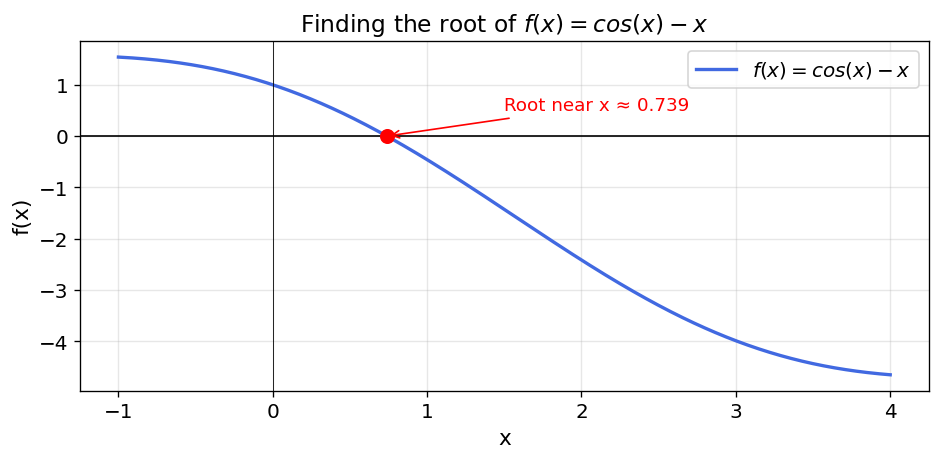

In [10]:
# Example: visualizing roots of a simple function
def f_demo(x):
    return np.cos(x) - x

x = np.linspace(-1, 4, 500)
y = f_demo(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, 'royalblue', label=r'$f(x) = cos(x) - x$')
ax.axhline(0, color='k', linewidth=1)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Finding the root of $f(x) = cos(x) - x$')
ax.legend()

# Mark approximate root
ax.annotate('Root near x ≈ 0.739', xy=(0.739, 0), xytext=(1.5, 0.5),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=11)
ax.plot(0.739, 0, 'ro', markersize=8)
plt.tight_layout()
plt.show()

---

## Part 1: Bracketing Methods

Bracketing methods are the safest class of root-finding algorithms. They require you to identify an **interval** $[a, b]$ that contains a root — guaranteed by the **Intermediate Value Theorem (IVT)**:

> If $f$ is continuous on $[a, b]$ and $f(a) \cdot f(b) < 0$, then there exists at least one $c \in (a, b)$ such that $f(c) = 0$.

In other words, if $f$ changes sign over an interval, it must cross zero somewhere in that interval. Bracketing methods systematically shrink this interval until the root is located to the desired precision.

The key **advantage** of bracketing methods is guaranteed convergence — as long as the bracket contains an odd number of roots and $f$ is continuous, the method will find a root. The **disadvantage** is that they can be slower than open methods.

---

### The Bisection Method (Binary Search)

The **bisection method** is the simplest bracketing algorithm. The idea is elegantly simple:

1. Start with a bracket $[a, b]$ where $f(a)$ and $f(b)$ have opposite signs.
2. Compute the midpoint: $c = \frac{a + b}{2}$
3. Evaluate $f(c)$.
4. If $f(c) = 0$, done! Otherwise, replace whichever endpoint has the same sign as $f(c)$:
   - If $f(a) \cdot f(c) < 0$, set $b = c$ (root is in left half)
   - If $f(b) \cdot f(c) < 0$, set $a = c$ (root is in right half)
5. Repeat until the bracket is smaller than the desired tolerance.

#### Convergence Analysis

After $n$ iterations, the bracket width is:

$\epsilon_n = \frac{b - a}{2^n}$

To achieve a tolerance $\epsilon$, we need:

$n \geq \log_2\left(\frac{b - a}{\epsilon}\right)$

This is called **linear convergence** (also called first-order convergence): each iteration gains exactly one bit of precision. While not the fastest method, bisection is highly robust.

**Example:** To find a root to 10 decimal places ($\epsilon \approx 10^{-10}$) on an interval of width 1, we need $n \approx \log_2(10^{10}) \approx 33$ iterations — very manageable!

In [11]:
def bisection(f, a, b, tol=1e-8, max_iter=100, verbose=False):
    """
    Find a root of f in [a, b] using the bisection method.
    
    Parameters
    ----------
    f        : callable, the function
    a, b     : float, bracket endpoints with f(a)*f(b) < 0
    tol      : float, stopping tolerance on bracket width
    max_iter : int, maximum iterations
    verbose  : bool, print iteration table if True
    
    Returns
    -------
    root     : float, approximate root
    history  : list of midpoints at each iteration
    """
    if f(a) * f(b) > 0:
        raise ValueError("f(a) and f(b) must have opposite signs!")
    
    history = []
    if verbose:
        print(f"{'Iter':>5}  {'a':>12}  {'b':>12}  {'c':>12}  {'f(c)':>12}  {'width':>12}")
        print("-" * 72)
    
    for i in range(max_iter):
        c = (a + b) / 2.0
        history.append(c)
        fc = f(c)
        width = b - a
        
        if verbose:
            print(f"{i+1:>5}  {a:>12.8f}  {b:>12.8f}  {c:>12.8f}  {fc:>12.6e}  {width:>12.6e}")
        
        if abs(fc) < tol or width / 2 < tol:
            return c, history
        
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    
    print(f"Warning: did not converge in {max_iter} iterations")
    return c, history

# Quick test: cos(x) = x  =>  cos(x) - x = 0
root, hist = bisection(f_demo, 0, 2, verbose=True)
print(f"\nRoot found: x = {root:.10f}")
print(f"Verification: f(root) = {f_demo(root):.2e}")

 Iter             a             b             c          f(c)         width
------------------------------------------------------------------------
    1    0.00000000    2.00000000    1.00000000  -4.596977e-01  2.000000e+00
    2    0.00000000    1.00000000    0.50000000  3.775826e-01  1.000000e+00
    3    0.50000000    1.00000000    0.75000000  -1.831113e-02  5.000000e-01
    4    0.50000000    0.75000000    0.62500000  1.859631e-01  2.500000e-01
    5    0.62500000    0.75000000    0.68750000  8.533495e-02  1.250000e-01
    6    0.68750000    0.75000000    0.71875000  3.387937e-02  6.250000e-02
    7    0.71875000    0.75000000    0.73437500  7.874725e-03  3.125000e-02
    8    0.73437500    0.75000000    0.74218750  -5.195712e-03  1.562500e-02
    9    0.73437500    0.74218750    0.73828125  1.345150e-03  7.812500e-03
   10    0.73828125    0.74218750    0.74023438  -1.923873e-03  3.906250e-03
   11    0.73828125    0.74023438    0.73925781  -2.890091e-04  1.953125e-03
   12    0

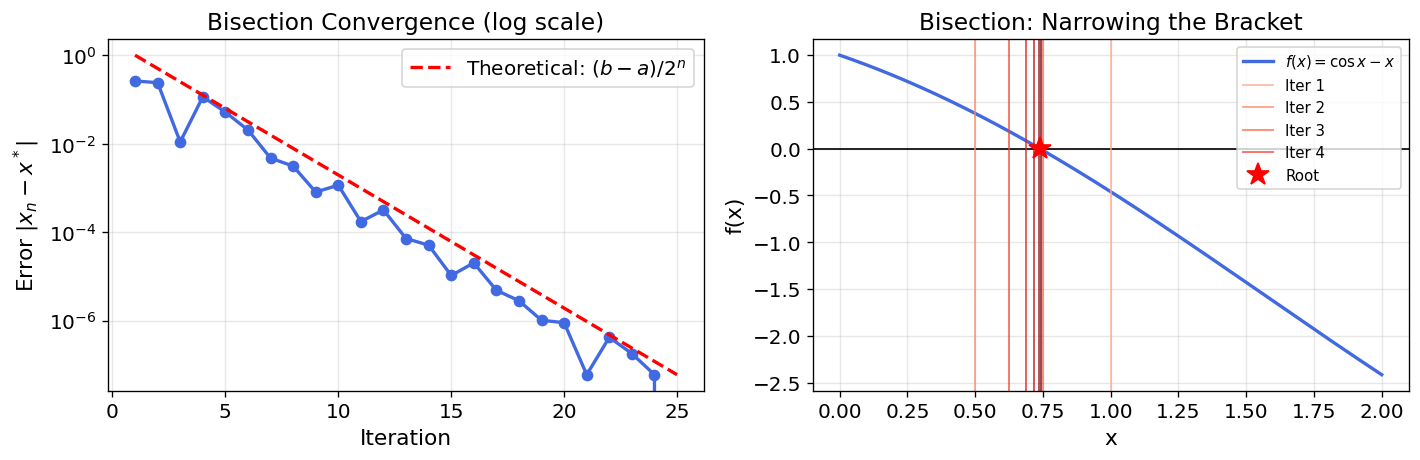

In [12]:
# Visualize the convergence of bisection
errors = [abs(h - root) for h in hist]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Error vs iteration
axes[0].semilogy(range(1, len(errors)+1), errors, 'o-', color='royalblue')
# Theoretical error envelope
n_vals = np.arange(1, len(errors)+1)
axes[0].semilogy(n_vals, 2.0 / 2**n_vals, 'r--', label='Theoretical: $(b-a)/2^n$')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error |$x_n - x^*$|')
axes[0].set_title('Bisection Convergence (log scale)')
axes[0].legend()

# Show narrowing brackets visually
x = np.linspace(0, 2, 400)
axes[1].plot(x, f_demo(x), 'royalblue', label=r'$f(x) = \cos x - x$')
axes[1].axhline(0, color='k', linewidth=1)
colors = plt.cm.Reds(np.linspace(0.3, 1.0, min(8, len(hist))))
for i, (h, c) in enumerate(zip(hist[:8], colors)):
    axes[1].axvline(h, color=c, alpha=0.7, linewidth=1.2, label=f'Iter {i+1}' if i < 4 else '')
axes[1].plot(root, 0, 'r*', markersize=14, label='Root')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('Bisection: Narrowing the Bracket')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### Physics Example 1.1: Projectile Range Equation

A projectile launched at speed $v_0 = 50$ m/s over a flat terrain must hit a target at range $R = 200$ m. Neglecting air resistance, the range formula is:

$R = \frac{v_0^2 \sin(2\theta)}{g}$

We want to find the launch angle $\theta$ that achieves this range. Rearranging:

$f(\theta) = \frac{v_0^2 \sin(2\theta)}{g} - R = 0$

Note: there are **two** solutions (complementary angles both give the same range), so we will find both by choosing different brackets.

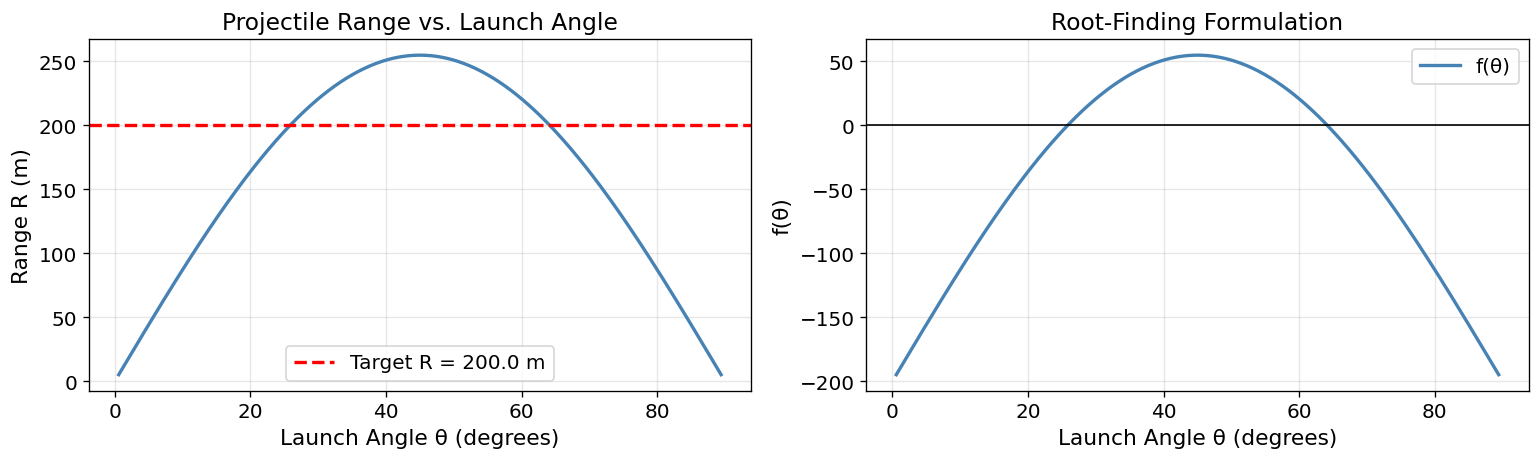

Solution 1: θ = 25.8511°
Solution 2: θ = 64.1489°
Note: 25.8511° + 64.1489° = 90.0000° (complementary angles)
Verification: R(θ1) = 200.0000 m


In [13]:
g  = 9.81   # m/s^2
v0 = 50.0   # m/s
R_target = 200.0  # m

def range_eq(theta):
    """f(theta) = v0^2 * sin(2*theta) / g - R"""
    return (v0**2 * np.sin(2 * theta) / g) - R_target

# Plot the range as a function of angle
theta_vals = np.linspace(0.01, np.pi/2 - 0.01, 400)
R_vals = v0**2 * np.sin(2 * theta_vals) / g

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.degrees(theta_vals), R_vals, 'steelblue')
axes[0].axhline(R_target, color='red', linestyle='--', label=f'Target R = {R_target} m')
axes[0].set_xlabel('Launch Angle θ (degrees)')
axes[0].set_ylabel('Range R (m)')
axes[0].set_title('Projectile Range vs. Launch Angle')
axes[0].legend()

axes[1].plot(np.degrees(theta_vals), range_eq(theta_vals), 'steelblue', label='f(θ)')
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_xlabel('Launch Angle θ (degrees)')
axes[1].set_ylabel('f(θ)')
axes[1].set_title('Root-Finding Formulation')
axes[1].legend()
plt.tight_layout()
plt.show()

# Find both solutions using different brackets
# Solution 1: low angle (< 45 deg)
theta1, _ = bisection(range_eq, 0.01, np.pi/4)
# Solution 2: high angle (> 45 deg)
theta2, _ = bisection(range_eq, np.pi/4, np.pi/2 - 0.01)

print(f"Solution 1: θ = {np.degrees(theta1):.4f}°")
print(f"Solution 2: θ = {np.degrees(theta2):.4f}°")
print(f"Note: {np.degrees(theta1):.4f}° + {np.degrees(theta2):.4f}° = {np.degrees(theta1+theta2):.4f}° (complementary angles)")
print(f"Verification: R(θ1) = {v0**2 * np.sin(2*theta1)/g:.4f} m")

### Physics Example 1.2: Finding Turning Points in a Potential Well

In classical mechanics, a particle of energy $E$ moving in a potential $V(x)$ is constrained to regions where $E \geq V(x)$. The **turning points** $x_1$ and $x_2$ are where kinetic energy equals zero:

$E - V(x) = 0$

Consider the **Morse potential**, a realistic model for diatomic molecular vibration:

$V(x) = D_e \left(1 - e^{-a(x - x_e)}\right)^2$

where $D_e$ is the dissociation energy, $a$ controls the well width, and $x_e$ is the equilibrium bond length. We will find the classical turning points for a particle with energy $E = 0.6 D_e$.

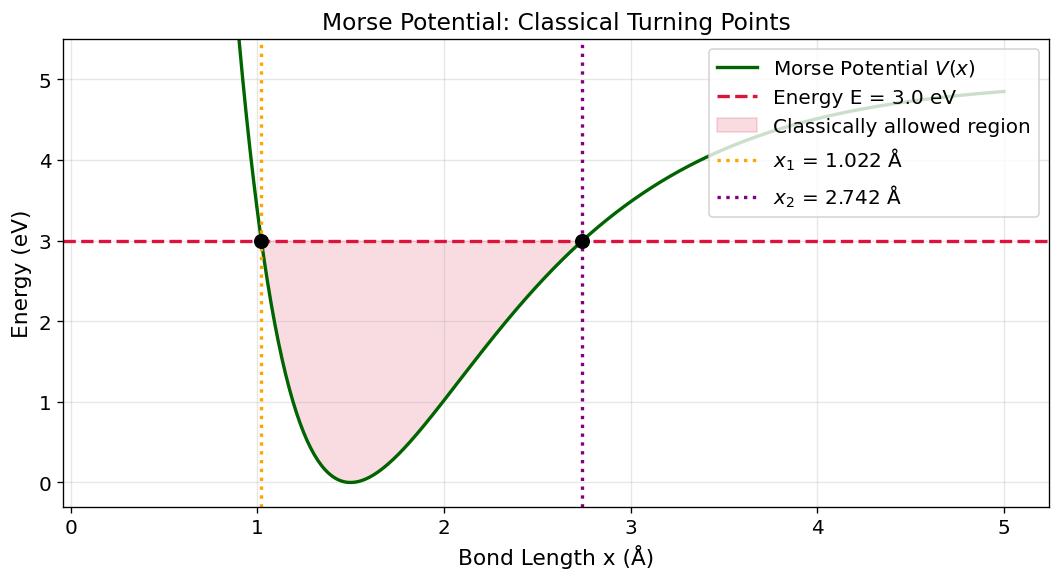

Left  turning point:  x1 = 1.022022 Å
Right turning point:  x2 = 2.741553 Å
Classical amplitude:  Δx = 1.719531 Å


In [14]:
# Morse potential parameters (arbitrary units, representative of a diatomic)
D_e = 5.0   # well depth (eV)
a   = 1.2   # inverse Angstrom
x_e = 1.5   # equilibrium bond length (Angstrom)
E   = 0.6 * D_e  # particle energy

def morse(x):
    return D_e * (1 - np.exp(-a * (x - x_e)))**2

def f_turning(x):
    """Root = turning point where E = V(x)"""
    return morse(x) - E

x = np.linspace(0.2, 5.0, 500)
V = morse(x)

# Find turning points
x1, _ = bisection(f_turning, 0.5, x_e)        # left turning point
x2, _ = bisection(f_turning, x_e, 4.5)        # right turning point

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, V, 'darkgreen', label='Morse Potential $V(x)$')
ax.axhline(E, color='crimson', linestyle='--', label=f'Energy E = {E:.1f} eV')
ax.fill_between(x, E, V, where=(V <= E), alpha=0.15, color='crimson', label='Classically allowed region')
ax.axvline(x1, color='orange', linestyle=':', linewidth=2, label=f'$x_1$ = {x1:.3f} Å')
ax.axvline(x2, color='purple', linestyle=':', linewidth=2, label=f'$x_2$ = {x2:.3f} Å')
ax.plot([x1, x2], [E, E], 'ko', markersize=8)
ax.set_xlabel('Bond Length x (Å)')
ax.set_ylabel('Energy (eV)')
ax.set_title('Morse Potential: Classical Turning Points')
ax.set_ylim(-0.3, D_e + 0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Left  turning point:  x1 = {x1:.6f} Å")
print(f"Right turning point:  x2 = {x2:.6f} Å")
print(f"Classical amplitude:  Δx = {x2 - x1:.6f} Å")

### Physics Example 1.3: Equilibrium Position of a Charge Between Two Fixed Charges

Two positive charges $Q_1 = 2\,\mu$C and $Q_2 = 5\,\mu$C are fixed at $x = 0$ and $x = L = 1$ m, respectively. Where should a third charge $q$ be placed on the line between them so that the net Coulomb force on it is zero?

By Coulomb's law, the force on $q$ at position $x$ (with $0 < x < L$) is:

$F(x) = \frac{kq}{x^2}\,Q_1 - \frac{kq}{(L-x)^2}\,Q_2 = 0$

Since $kq \neq 0$, we need:

$f(x) = \frac{Q_1}{x^2} - \frac{Q_2}{(L-x)^2} = 0$

This can be solved analytically, but it serves as a clean demonstration of bisection.

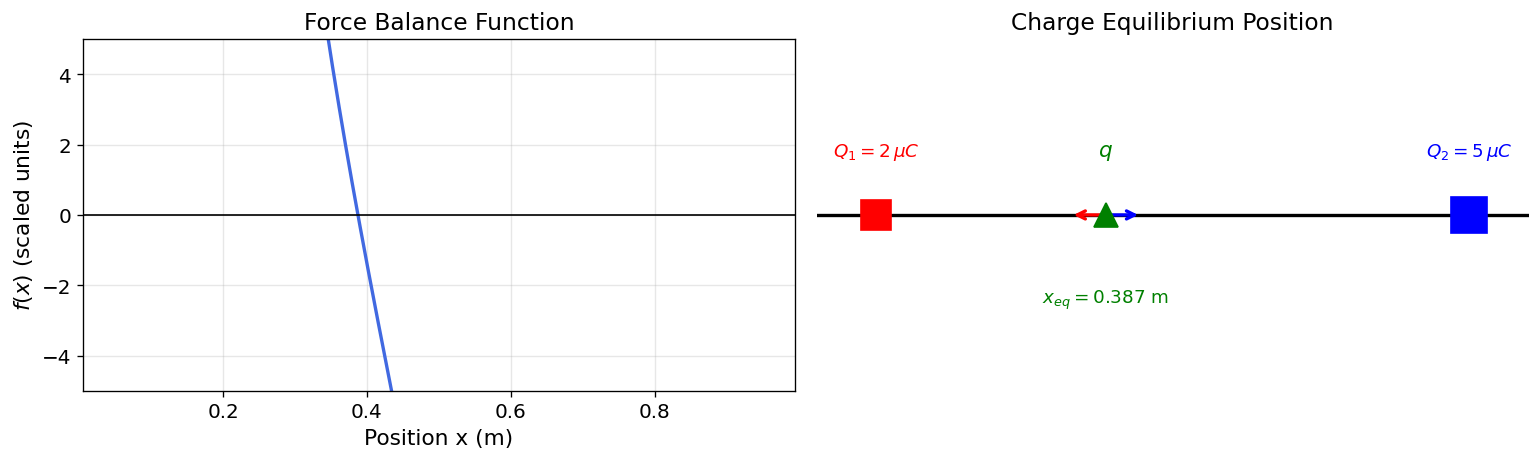

Bisection result:   x_eq = 0.38742676 m
Analytical result:  x_eq = 0.38742589 m
Error: 8.71e-07 m


In [15]:
Q1 = 2e-6   # Coulombs
Q2 = 5e-6   # Coulombs
L  = 1.0    # meters

def force_balance(x):
    return Q1 / x**2 - Q2 / (L - x)**2

x_vals = np.linspace(0.05, 0.95, 400)
f_vals = force_balance(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_vals, f_vals * 1e6, 'royalblue')  # scale for readability
axes[0].axhline(0, color='k', linewidth=1)
axes[0].set_xlabel('Position x (m)')
axes[0].set_ylabel(r'$f(x)$ (scaled units)')
axes[0].set_title('Force Balance Function')
axes[0].set_ylim(-5, 5)

x_eq, _ = bisection(force_balance, 0.05, 0.9)

# Schematic diagram
ax2 = axes[1]
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.3, 0.3)
ax2.axhline(0, color='k', linewidth=2)
ax2.plot(0, 0, 'rs', markersize=18, zorder=5)
ax2.plot(L, 0, 'bs', markersize=22, zorder=5)
ax2.plot(x_eq, 0, 'g^', markersize=14, zorder=5)
ax2.text(0, 0.1, r'$Q_1 = 2\,\mu C$', ha='center', fontsize=11, color='red')
ax2.text(L, 0.1, r'$Q_2 = 5\,\mu C$', ha='center', fontsize=11, color='blue')
ax2.text(x_eq, -0.15, f'$x_{{eq}} = {x_eq:.3f}$ m', ha='center', fontsize=11, color='green')
ax2.text(x_eq, 0.1, '$q$', ha='center', fontsize=13, color='green')
# Arrows showing forces
ax2.annotate('', xy=(x_eq + 0.06, 0), xytext=(x_eq, 0),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax2.annotate('', xy=(x_eq - 0.06, 0), xytext=(x_eq, 0),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax2.set_title('Charge Equilibrium Position')
ax2.axis('off')
plt.tight_layout()
plt.show()

# Analytical solution for comparison: Q1/(x^2) = Q2/(L-x)^2 => sqrt(Q1)*(L-x) = sqrt(Q2)*x
x_analytical = L * np.sqrt(Q1) / (np.sqrt(Q1) + np.sqrt(Q2))
print(f"Bisection result:   x_eq = {x_eq:.8f} m")
print(f"Analytical result:  x_eq = {x_analytical:.8f} m")
print(f"Error: {abs(x_eq - x_analytical):.2e} m")

---

### The False Position Method (Regula Falsi)

The **false position method** (Latin: *regula falsi*, "rule of false") is a refinement of bisection. Instead of always choosing the midpoint of $[a, b]$, it uses the **linear interpolation** between the two endpoints to estimate where $f$ crosses zero:

$c = b - f(b)\cdot\frac{b - a}{f(b) - f(a)}$

Geometrically, this is the $x$-intercept of the straight line connecting the points $(a, f(a))$ and $(b, f(b))$.

The bracket update rule is the same as bisection: replace whichever endpoint has the same sign as $f(c)$.

**When does false position beat bisection?**  
When $f$ is roughly linear near the root, false position converges faster. However, it can be **slower** than bisection if the function is highly curved — one endpoint may never be updated (this is the "Illinois problem"). The modified Illinois algorithm fixes this, but we will not cover it here.

**Convergence:** False position has **superlinear** convergence in favorable cases — somewhere between linear (bisection) and quadratic (Newton's method).

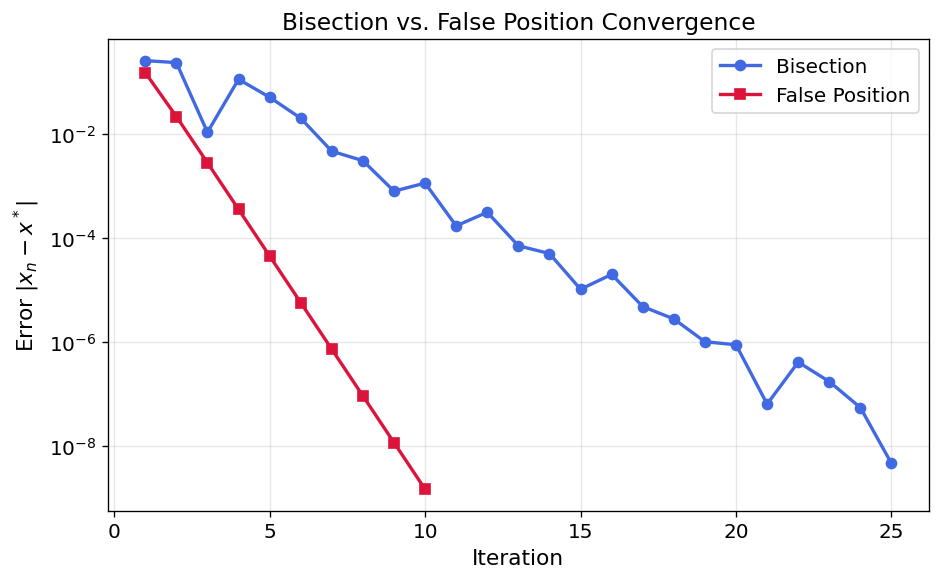

Bisection converged in 25 iterations
False Position converged in 10 iterations


In [16]:
def false_position(f, a, b, tol=1e-8, max_iter=100, verbose=False):
    """
    Find a root of f in [a,b] using the false position (regula falsi) method.
    """
    if f(a) * f(b) > 0:
        raise ValueError("f(a) and f(b) must have opposite signs!")
    
    history = []
    if verbose:
        print(f"{'Iter':>5}  {'a':>12}  {'b':>12}  {'c':>12}  {'f(c)':>12}")
        print("-" * 62)
    
    fa, fb = f(a), f(b)
    for i in range(max_iter):
        # Linear interpolation
        c = b - fb * (b - a) / (fb - fa)
        fc = f(c)
        history.append(c)
        
        if verbose:
            print(f"{i+1:>5}  {a:>12.8f}  {b:>12.8f}  {c:>12.8f}  {fc:>12.6e}")
        
        if abs(fc) < tol:
            return c, history
        
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    
    return c, history

# Compare bisection vs false position on the cos(x)-x problem
root_fp, hist_fp = false_position(f_demo, 0, 2)
root_bi, hist_bi = bisection(f_demo, 0, 2)

true_root = 0.7390851332151607  # known value

err_fp = [abs(h - true_root) for h in hist_fp]
err_bi = [abs(h - true_root) for h in hist_bi]

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(range(1, len(err_bi)+1), err_bi, 'o-', color='royalblue', label='Bisection')
ax.semilogy(range(1, len(err_fp)+1), err_fp, 's-', color='crimson', label='False Position')
ax.set_xlabel('Iteration')
ax.set_ylabel('Error |$x_n - x^*$|')
ax.set_title('Bisection vs. False Position Convergence')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Bisection converged in {len(hist_bi)} iterations")
print(f"False Position converged in {len(hist_fp)} iterations")

### Physics Example 1.4: Wien's Displacement Law

**Blackbody radiation** is described by Planck's law. The wavelength $\lambda_{\max}$ at which a blackbody of temperature $T$ emits most intensely is given by **Wien's displacement law**:

$\lambda_{\max} = \frac{b}{T}$

where $b \approx 2.898 \times 10^{-3}$ m·K. But how is this constant derived?

Planck's law gives the spectral radiance as a function of wavelength:

$B(\lambda, T) = \frac{2hc^2}{\lambda^5} \cdot \frac{1}{e^{hc/(\lambda k_B T)} - 1}$

Setting $dB/d\lambda = 0$ and letting $u = hc/(\lambda k_B T)$, we get the **transcendental equation**:

$5(1 - e^{-u}) = u$

or equivalently:

$f(u) = 5 (1 - e^{-u}) - u = 0, \quad u > 0$

We'll solve this numerically to derive Wien's constant!

In [ ]:
# Wien displacement law derivation
def wien_eq(u):
    """f(u) = 5*(1 - e^{-u}) - u  =  0"""
    return 5 * (1 - np.exp(-u)) - u

u_vals = np.linspace(0.1, 10, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(u_vals, wien_eq(u_vals), 'darkviolet', label='$f(u) = 5(1-e^{-u}) - u$')
axes[0].axhline(0, color='k', linewidth=1)
axes[0].set_xlabel('u')
axes[0].set_ylabel('f(u)')
axes[0].set_title("Wien's Law: Finding $u = hc/(\\lambda_{max} k_B T)$")
axes[0].legend()

# Solve for u
u_root, hist_u = bisection(wien_eq, 2.0, 8.0)

# Physical constants
h  = 6.626e-34   # J*s
c  = 3.0e8       # m/s
k_B = 1.381e-23  # J/K

# Wien constant: b = h*c / (k_B * u_root)
b_computed = h * c / (k_B * u_root)
b_accepted = 2.898e-3  # m*K

print(f"Solution: u = {u_root:.8f}")
print(f"Wien constant (computed): b = {b_computed:.5e} m·K")
print(f"Wien constant (accepted): b = {b_accepted:.5e} m·K")
print(f"Relative error: {abs(b_computed - b_accepted)/b_accepted * 100:.4f}%")

# Now plot Planck's distribution for the Sun (T = 5778 K)
T_sun = 5778  # K
lam = np.linspace(100e-9, 3000e-9, 1000)  # 100 nm to 3000 nm
B = (2*h*c**2 / lam**5) / (np.exp(h*c/(lam*k_B*T_sun)) - 1)
lam_max = b_computed / T_sun

axes[1].plot(lam * 1e9, B / B.max(), 'darkorange', label=f'Planck spectrum (T = {T_sun} K)')
axes[1].axvline(lam_max * 1e9, color='red', linestyle='--',
                label=f'$\\lambda_{{max}}$ = {lam_max*1e9:.0f} nm')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel('Normalized Spectral Radiance')
axes[1].set_title("Sun's Blackbody Spectrum")
axes[1].legend()
# Shade visible spectrum roughly
axes[1].axvspan(380, 700, alpha=0.1, color='yellow', label='Visible')
plt.tight_layout()
plt.show()

---

## Part 2: Newton-Raphson Method

Newton's method (also called the Newton-Raphson method) is one of the most powerful and widely used root-finding algorithms. Unlike bracketing methods, it is an **open method** — it does not require an initial bracket, only a starting guess $x_0$.

### Derivation

The idea is to approximate $f(x)$ by its **tangent line** at the current guess $x_n$, and use the root of that tangent line as the next guess.

The Taylor expansion of $f$ around $x_n$ is:

$f(x) \approx f(x_n) + f'(x_n)(x - x_n)$

Setting $f(x) = 0$ and solving for $x$:

$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$

This is the **Newton-Raphson iteration formula**. At each step, we:
1. Evaluate $f(x_n)$ and $f'(x_n)$
2. Compute the step: $\delta = -f(x_n)/f'(x_n)$
3. Update: $x_{n+1} = x_n + \delta$

### Convergence Analysis

Newton's method has **quadratic convergence** near a simple root. This means the number of correct decimal digits roughly doubles with each iteration. More precisely:

$|e_{n+1}| \approx \frac{|f''(x^*)|}{2|f'(x^*)|} |e_n|^2$

where $e_n = x_n - x^*$ is the error at step $n$.

**Example:** If you have 3 correct digits, the next iteration gives ~6, then ~12, then ~24 — spectacular convergence!

### Cautions and Pitfalls

- **Requires $f'(x_n) \neq 0$** at each step (division by zero otherwise)
- **Can diverge** if the initial guess is too far from the root or if $f$ has inflection points, local extrema, or oscillatory behavior near the root
- **May cycle** between values without converging
- For multiple roots ($f(x^*)=f'(x^*)=0$), convergence degrades to linear

A good strategy is to first use bisection to get a rough bracket, then switch to Newton's method for rapid final convergence.

In [ ]:
def newton(f, df, x0, tol=1e-10, max_iter=50, verbose=False):
    """
    Newton-Raphson method for root finding.
    
    Parameters
    ----------
    f        : callable, the function
    df       : callable, the derivative of f
    x0       : float, initial guess
    tol      : float, convergence tolerance
    max_iter : int, maximum iterations
    verbose  : bool, print iteration table
    
    Returns
    -------
    root     : float
    history  : list of iterates
    """
    x = x0
    history = [x]
    
    if verbose:
        print(f"{'Iter':>5}  {'x_n':>15}  {'f(x_n)':>14}  {'f\'(x_n)':>14}  {'step':>14}")
        print("-" * 70)
    
    for i in range(max_iter):
        fx  = f(x)
        dfx = df(x)
        
        if abs(dfx) < 1e-30:
            raise ZeroDivisionError(f"Derivative too small at x = {x}")
        
        step = -fx / dfx
        x_new = x + step
        
        if verbose:
            print(f"{i+1:>5}  {x:>15.10f}  {fx:>14.6e}  {dfx:>14.6e}  {step:>14.6e}")
        
        history.append(x_new)
        
        if abs(step) < tol:
            return x_new, history
        
        x = x_new
    
    print(f"Warning: did not converge in {max_iter} iterations")
    return x, history

# Demonstrate on cos(x) - x = 0
f_cos  = lambda x: np.cos(x) - x
df_cos = lambda x: -np.sin(x) - 1

root_nr, hist_nr = newton(f_cos, df_cos, x0=1.0, verbose=True)
print(f"\nRoot: {root_nr:.12f}")

In [ ]:
# Visualize Newton's method geometrically
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_plot = np.linspace(0, 2, 400)
ax = axes[0]
ax.plot(x_plot, f_cos(x_plot), 'royalblue', linewidth=2, label='$f(x) = \\cos x - x$')
ax.axhline(0, color='k', linewidth=1)

colors_nr = ['tomato', 'darkorange', 'gold', 'limegreen']
x_cur = 1.0
for i, col in enumerate(colors_nr[:min(4, len(hist_nr)-1)]):
    fx_cur = f_cos(x_cur)
    dfx_cur = df_cos(x_cur)
    x_next = x_cur - fx_cur / dfx_cur
    # Draw vertical drop to curve
    ax.plot([x_cur, x_cur], [0, fx_cur], color=col, linestyle='--', linewidth=1.2)
    # Draw tangent line
    x_tang = np.linspace(x_cur - 0.5, x_cur + 0.5, 50)
    ax.plot(x_tang, fx_cur + dfx_cur * (x_tang - x_cur), color=col, linewidth=1.5,
            label=f'Tangent at $x_{i}$={x_cur:.3f}')
    ax.plot(x_next, 0, 'v', color=col, markersize=10)
    ax.plot(x_cur, fx_cur, 'o', color=col, markersize=8)
    x_cur = x_next

ax.plot(root_nr, 0, 'r*', markersize=16, label='Root', zorder=10)
ax.set_xlim(0, 2)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title("Newton's Method: Geometric View")
ax.legend(fontsize=9)

# Convergence comparison
true_root = 0.7390851332151607
err_nr = [abs(h - true_root) for h in hist_nr[:-1]]
err_bi2 = [abs(h - true_root) for h in hist_bi]

axes[1].semilogy(range(1, len(err_bi2)+1), err_bi2, 'o-', color='royalblue',
                 label='Bisection (linear)')
axes[1].semilogy(range(1, len(err_nr)+1), err_nr, 's-', color='crimson',
                 label="Newton (quadratic)")
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Error')
axes[1].set_title('Convergence Comparison')
axes[1].legend()
plt.tight_layout()
plt.show()

print("Newton's method converges dramatically faster!")

### Physics Example 2.1: Relativistic Kinetic Energy

In special relativity, the kinetic energy of a particle with rest mass $m$ and velocity $v$ is:

$K = (\gamma - 1)mc^2, \quad \gamma = \frac{1}{\sqrt{1 - v^2/c^2}}$

Given a kinetic energy $K = 500$ MeV and rest mass energy $mc^2 = 938.3$ MeV (a proton), find the velocity $\beta = v/c$.

Rearranging:

$f(\beta) = \frac{1}{\sqrt{1-\beta^2}} - 1 - \frac{K}{mc^2} = 0$

The derivative is:

$f'(\beta) = \frac{\beta}{(1-\beta^2)^{3/2}}$

In [ ]:
mc2 = 938.3   # MeV (proton rest mass energy)
K   = 500.0   # MeV (kinetic energy)

def relativistic_f(beta):
    gamma = 1.0 / np.sqrt(1 - beta**2)
    return (gamma - 1) * mc2 - K

def relativistic_df(beta):
    return mc2 * beta / (1 - beta**2)**1.5

# Plot the function
beta_vals = np.linspace(0.01, 0.999, 500)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta_vals, relativistic_f(beta_vals), 'steelblue')
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel(r'$\beta = v/c$')
ax.set_ylabel(r'$f(\beta)$  (MeV)')
ax.set_title(r'Relativistic Kinetic Energy: Find $\beta$ for $K = 500$ MeV')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

beta_root, beta_hist = newton(relativistic_f, relativistic_df, x0=0.5, verbose=True)
v = beta_root * 3e8  # m/s
gamma_final = 1 / np.sqrt(1 - beta_root**2)

print(f"\nResult:")
print(f"  β = v/c = {beta_root:.8f}")
print(f"  v = {v:.5e} m/s")
print(f"  γ (Lorentz factor) = {gamma_final:.5f}")
print(f"  K = (γ-1)mc² = {(gamma_final - 1)*mc2:.4f} MeV  (should be {K} MeV)")

# Comparison: non-relativistic formula
# K = 1/2 mv^2  =>  beta = sqrt(2K/mc2)
beta_nonrel = np.sqrt(2 * K / mc2)
print(f"\nNon-relativistic estimate: β = {beta_nonrel:.4f}  (WRONG — too slow limit)")
print(f"At β = {beta_root:.4f}, the relativistic correction is significant!")

### Physics Example 2.2: Kepler's Equation (Orbital Mechanics)

**Kepler's Equation** relates the mean anomaly $M$ (proportional to time) to the eccentric anomaly $E$ for an elliptical orbit:

$M = E - e\sin(E)$

where $e$ is the orbital eccentricity ($0 \leq e < 1$). Given $M$ and $e$, we must solve for $E$:

$f(E) = E - e\sin(E) - M = 0$

This is a **transcendental equation** — no closed-form solution exists. Kepler himself struggled with it.

The derivative is straightforward:

$f'(E) = 1 - e\cos(E)$

Newton's method works beautifully here because $f'(E) \geq 1 - e > 0$ for $e < 1$, so we are guaranteed to converge from any starting point.

We will solve this for **Mars** ($e = 0.0934$) and a **highly eccentric comet** ($e = 0.97$).

In [ ]:
def solve_kepler(M, e, x0=None, tol=1e-12):
    """Solve Kepler's equation M = E - e*sin(E) for E."""
    if x0 is None:
        x0 = M  # M is always a good starting guess
    
    f  = lambda E: E - e * np.sin(E) - M
    df = lambda E: 1 - e * np.cos(E)
    E_sol, hist = newton(f, df, x0, tol=tol)
    return E_sol, hist

# Solve for many mean anomalies (full orbit)
M_vals = np.linspace(0, 2*np.pi, 200)

e_mars  = 0.0934
e_comet = 0.97

E_mars  = np.array([solve_kepler(M, e_mars)[0]  for M in M_vals])
E_comet = np.array([solve_kepler(M, e_comet)[0] for M in M_vals])

# Convert eccentric anomaly to Cartesian position
def orbital_position(E_arr, e, a=1.0):
    """Ellipse: x = a*(cos(E)-e), y = a*sqrt(1-e^2)*sin(E)"""
    x = a * (np.cos(E_arr) - e)
    y = a * np.sqrt(1 - e**2) * np.sin(E_arr)
    return x, y

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: eccentric anomaly vs mean anomaly
axes[0].plot(np.degrees(M_vals), np.degrees(E_mars),  'steelblue', label=f'Mars (e={e_mars})')
axes[0].plot(np.degrees(M_vals), np.degrees(E_comet), 'crimson',   label=f'Comet (e={e_comet})')
axes[0].plot([0,360],[0,360], 'k--', linewidth=1, label='E = M (circular)')
axes[0].set_xlabel('Mean Anomaly M (degrees)')
axes[0].set_ylabel('Eccentric Anomaly E (degrees)')
axes[0].set_title("Kepler's Equation Solution")
axes[0].legend(fontsize=10)

# Middle: Mars orbit
x_m, y_m = orbital_position(E_mars, e_mars)
axes[1].plot(x_m, y_m, 'steelblue', linewidth=2, label='Mars orbit')
axes[1].plot(0, 0, 'yo', markersize=16, label='Sun', zorder=5)
# Color points by time (M)
sc = axes[1].scatter(x_m[::5], y_m[::5], c=M_vals[::5], cmap='plasma', s=30, zorder=4)
axes[1].set_aspect('equal')
axes[1].set_title(f'Mars Orbit (e = {e_mars})')
axes[1].set_xlabel('x (AU)')
axes[1].set_ylabel('y (AU)')
axes[1].legend()

# Right: comet orbit
x_c, y_c = orbital_position(E_comet, e_comet)
axes[2].plot(x_c, y_c, 'crimson', linewidth=2, label='Comet orbit')
axes[2].plot(0, 0, 'yo', markersize=16, label='Sun', zorder=5)
sc2 = axes[2].scatter(x_c[::5], y_c[::5], c=M_vals[::5], cmap='plasma', s=30, zorder=4)
axes[2].set_aspect('equal')
axes[2].set_title(f'Comet Orbit (e = {e_comet})')
axes[2].set_xlabel('x (AU)')
axes[2].set_ylabel('y (AU)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Show fast convergence for a specific case
M_test = np.pi / 3  # 60 degrees
E_sol, hist_k = solve_kepler(M_test, e_comet, tol=1e-12)
print(f"Kepler's equation for comet at M = {np.degrees(M_test):.1f}°:")
print(f"  Eccentric anomaly E = {np.degrees(E_sol):.8f}°")
print(f"  Converged in {len(hist_k)-1} Newton iterations")
print(f"  Verification: E - e*sin(E) = {E_sol - e_comet*np.sin(E_sol):.12f}")
print(f"              M             = {M_test:.12f}")

### Physics Example 2.3: Index of Refraction and Snell's Law Inversion

A common problem in optics is finding the angle of refraction given measured data. Suppose light travels from a medium with refractive index $n_1 = 1.0$ (air) at incident angle $\theta_1 = 45°$ and we want to find $\theta_2$ in a medium where the refractive index depends on wavelength (dispersion):

$n_2(\lambda) = A + \frac{B}{\lambda^2}$

(**Cauchy's equation**, where $\lambda$ is in $\mu$m, $A = 1.4580$, $B = 0.00354$ for crown glass)

Snell's law: $n_1 \sin(\theta_1) = n_2(\lambda) \sin(\theta_2)$

Here this is analytically trivial (just invert $\sin$), but we'll extend to a more complex geometry where the ray must hit a target point after refraction, so we solve:

$f(\theta_2) = d\,\tan(\theta_2) - x_{\text{target}} = 0$

where $d$ is the glass thickness and $x_{\text{target}}$ is the target horizontal offset.

In [ ]:
# Dispersion: Cauchy equation for crown glass
A, B = 1.4580, 0.00354   # Cauchy coefficients

def n_glass(lam_um):  # lambda in micrometers
    return A + B / lam_um**2

wavelengths_nm = np.array([400, 450, 500, 550, 600, 650, 700])  # visible spectrum
lam_um = wavelengths_nm / 1000.0
n_vals = n_glass(lam_um)

theta1_deg = 45.0
theta1 = np.radians(theta1_deg)
n1 = 1.0

# Refraction angles via Snell's law
theta2_arr = np.arcsin(n1 * np.sin(theta1) / n_vals)

# Lateral displacement through glass slab of thickness d
d = 10.0  # mm
lateral_disp = d * (np.tan(theta1) - np.tan(theta2_arr))

# Now use Newton's method for the inverse problem:
# Given a target lateral displacement d_target, find the required n2
d_target = 2.5  # mm lateral shift desired

def f_lateral(n2):
    t2 = np.arcsin(n1 * np.sin(theta1) / n2)
    return d * (np.tan(theta1) - np.tan(t2)) - d_target

def df_lateral(n2):
    sin_t2 = n1 * np.sin(theta1) / n2
    cos_t2 = np.sqrt(1 - sin_t2**2)
    # d/dn2 of tan(arcsin(n1*sin(t1)/n2))
    dtan_dn2 = (-n1 * np.sin(theta1) / n2**2) / (cos_t2**3)
    return -d * dtan_dn2

n2_required, _ = newton(f_lateral, df_lateral, x0=1.5)

# Find the corresponding wavelength using Cauchy equation
def f_cauchy(lam):
    return n_glass(lam) - n2_required
lam_required_um, _ = bisection(f_cauchy, 0.38, 0.75)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot dispersion curve
lam_fine = np.linspace(0.38, 0.75, 300)
axes[0].plot(lam_fine * 1000, n_glass(lam_fine), 'purple', label='Crown glass (Cauchy)')
axes[0].scatter(wavelengths_nm, n_vals, c=['violet','blue','cyan','green','orange','red','darkred'],
                s=80, zorder=5)
axes[0].axhline(n2_required, color='k', linestyle='--', label=f'Required n = {n2_required:.4f}')
axes[0].axvline(lam_required_um*1000, color='grey', linestyle=':', 
                label=f'λ = {lam_required_um*1000:.1f} nm')
axes[0].set_xlabel('Wavelength (nm)')
axes[0].set_ylabel('Refractive Index n')
axes[0].set_title('Dispersion Curve: Crown Glass')
axes[0].legend()

# Plot lateral displacement vs wavelength
lam_all = np.linspace(0.38, 0.75, 200)
n_all = n_glass(lam_all)
t2_all = np.arcsin(n1 * np.sin(theta1) / n_all)
disp_all = d * (np.tan(theta1) - np.tan(t2_all))

axes[1].plot(lam_all * 1000, disp_all, 'steelblue')
axes[1].axhline(d_target, color='red', linestyle='--', label=f'Target: {d_target} mm')
axes[1].axvline(lam_required_um*1000, color='grey', linestyle=':',
                label=f'λ = {lam_required_um*1000:.1f} nm')
axes[1].set_xlabel('Wavelength (nm)')
axes[1].set_ylabel('Lateral Displacement (mm)')
axes[1].set_title('Lateral Displacement through 10 mm Glass')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Required refractive index: n = {n2_required:.6f}")
print(f"Corresponding wavelength:  λ = {lam_required_um*1000:.2f} nm")

### Physics Example 2.4: Period of a Simple Pendulum (Large Amplitude)

For a simple pendulum of length $L$, the exact period (valid for large angles) is:

$T(\theta_0) = 4\sqrt{\frac{L}{g}} \int_0^{\pi/2} \frac{d\phi}{\sqrt{1 - k^2\sin^2\phi}}$

where $k = \sin(\theta_0/2)$ and $\theta_0$ is the initial amplitude. This is the **complete elliptic integral of the first kind** $K(k)$.

The small-angle approximation gives $T_0 = 2\pi\sqrt{L/g}$.

**Problem:** Given a measured period $T_{\text{meas}}$, find the amplitude $\theta_0$. We define:

$f(\theta_0) = 4\sqrt{\frac{L}{g}}\,K(\sin(\theta_0/2)) - T_{\text{meas}} = 0$

We use `scipy.special.ellipk` for the elliptic integral and compute the derivative numerically.

In [ ]:
from scipy.special import ellipk

L = 1.0   # pendulum length in meters
g = 9.81  # m/s^2

T0 = 2 * np.pi * np.sqrt(L / g)  # small-angle period

def pendulum_period(theta0):
    """Exact period as a function of amplitude theta0 (radians)."""
    k = np.sin(theta0 / 2)
    return 4 * np.sqrt(L / g) * ellipk(k**2)

theta_arr = np.linspace(0.001, np.pi * 0.99, 400)
T_arr     = np.vectorize(pendulum_period)(theta_arr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.degrees(theta_arr), T_arr, 'royalblue', label='Exact period')
axes[0].axhline(T0, color='red', linestyle='--', label=f'Small-angle T₀ = {T0:.3f} s')
axes[0].set_xlabel('Amplitude θ₀ (degrees)')
axes[0].set_ylabel('Period T (s)')
axes[0].set_title('Pendulum Period vs. Amplitude (L = 1 m)')
axes[0].legend()

# Inverse problem: find theta_0 given measured period
T_measured = 2.20  # seconds — much longer than T0 = 2.006 s

def f_period(theta0):
    return pendulum_period(theta0) - T_measured

# Numerical derivative using central differences
def df_period(theta0, h=1e-6):
    return (f_period(theta0 + h) - f_period(theta0 - h)) / (2 * h)

theta_solution, theta_hist = newton(f_period, df_period, x0=1.0)  # start at 1 rad

axes[1].plot(np.degrees(theta_arr), T_arr, 'royalblue')
axes[1].axhline(T_measured, color='red', linestyle='--', label=f'$T_{{meas}}$ = {T_measured} s')
axes[1].axvline(np.degrees(theta_solution), color='darkorange', linestyle=':',
                label=f'$\\theta_0$ = {np.degrees(theta_solution):.2f}°')
axes[1].plot(np.degrees(theta_solution), T_measured, 'r*', markersize=14)
axes[1].set_xlabel('Amplitude θ₀ (degrees)')
axes[1].set_ylabel('Period T (s)')
axes[1].set_title('Inverse Problem: Period → Amplitude')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Measured period:      T = {T_measured:.4f} s")
print(f"Small-angle period:  T₀ = {T0:.4f} s")
print(f"Inferred amplitude: θ₀ = {np.degrees(theta_solution):.4f}°")
print(f"Verification: T(θ₀) = {pendulum_period(theta_solution):.6f} s")
print(f"Newton converged in {len(theta_hist)-1} iterations")

---

## Part 3: The Secant Method

Newton's method requires us to evaluate the **derivative** $f'(x)$ at each step. Sometimes:
- The derivative is difficult or expensive to compute analytically
- The function is only known numerically (from experimental data or a simulation)
- We want to avoid the effort of finding the derivative formula

The **secant method** approximates the derivative using a **finite difference** between the two most recent iterates:

$f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}$

Substituting into the Newton formula:

$x_{n+1} = x_n - f(x_n) \cdot \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$

### Geometric Interpretation

Whereas Newton's method uses the **tangent line** (touching the curve at one point), the secant method uses a **secant line** (connecting two points on the curve). The next iterate is the $x$-intercept of this secant line.

### Convergence Analysis

The secant method has **superlinear convergence** with order $\phi \approx 1.618$ (the golden ratio!):

$|e_{n+1}| \approx C\,|e_n|^{\phi}, \quad \phi = \frac{1+\sqrt{5}}{2} \approx 1.618$

This is slower than Newton ($\phi = 2$) but faster than bisection ($\phi = 1$). And crucially, it requires only **one** new function evaluation per iteration (compared to Newton's two: $f$ and $f'$).

### Requirements
- Requires **two** initial guesses $x_0$ and $x_1$ (they do not need to bracket the root)
- Can fail if $f(x_n) \approx f(x_{n-1})$ (flat secant → near-division-by-zero)

In [ ]:
def secant(f, x0, x1, tol=1e-10, max_iter=50, verbose=False):
    """
    Secant method for root finding.
    
    Parameters
    ----------
    f        : callable
    x0, x1  : float, two initial guesses
    tol      : float, convergence tolerance
    max_iter : int
    verbose  : bool
    
    Returns
    -------
    root     : float
    history  : list
    """
    history = [x0, x1]
    f0, f1 = f(x0), f(x1)
    
    if verbose:
        print(f"{'Iter':>5}  {'x_n':>15}  {'f(x_n)':>14}  {'step':>14}")
        print("-" * 55)
        print(f"{'0':>5}  {x0:>15.10f}  {f0:>14.6e}")
        print(f"{'1':>5}  {x1:>15.10f}  {f1:>14.6e}")
    
    for i in range(max_iter):
        if abs(f1 - f0) < 1e-30:
            raise ZeroDivisionError("Secant denominator too small — method failed.")
        
        step  = -f1 * (x1 - x0) / (f1 - f0)
        x_new = x1 + step
        f_new = f(x_new)
        
        if verbose:
            print(f"{i+2:>5}  {x_new:>15.10f}  {f_new:>14.6e}  {step:>14.6e}")
        
        history.append(x_new)
        
        if abs(step) < tol:
            return x_new, history
        
        x0, f0 = x1, f1
        x1, f1 = x_new, f_new
    
    print(f"Warning: did not converge in {max_iter} iterations")
    return x1, history

# Demonstrate on cos(x) - x
root_sec, hist_sec = secant(f_cos, 0.5, 1.5, verbose=True)
print(f"\nRoot: {root_sec:.12f}")

In [ ]:
# Compare convergence rates of all three methods
true_root = 0.7390851332151607

_, hist_bi_   = bisection(f_cos, 0.0, 2.0, tol=1e-12)
_, hist_nr_   = newton(f_cos, df_cos, x0=1.0, tol=1e-12)
_, hist_sec_  = secant(f_cos, 0.5, 1.5, tol=1e-12)

err_bi_  = [abs(h - true_root) for h in hist_bi_  if abs(h - true_root) > 0]
err_nr_  = [abs(h - true_root) for h in hist_nr_  if abs(h - true_root) > 0]
err_sec_ = [abs(h - true_root) for h in hist_sec_ if abs(h - true_root) > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(range(1, len(err_bi_)+1),  err_bi_,  'o-', color='royalblue', label='Bisection (order 1)')
ax.semilogy(range(1, len(err_sec_)+1), err_sec_, 's-', color='darkorange', label='Secant (order ≈ 1.618)')
ax.semilogy(range(1, len(err_nr_)+1),  err_nr_,  '^-', color='crimson', label='Newton-Raphson (order 2)')
ax.set_xlabel('Iteration Number')
ax.set_ylabel('Absolute Error $|x_n - x^*|$')
ax.set_title('Convergence Rate Comparison: $\\cos(x) - x = 0$')
ax.legend(fontsize=11)
ax.set_ylim(1e-16, 2)
plt.tight_layout()
plt.show()

print(f"Bisection:         {len(hist_bi_)} iterations")
print(f"Secant:            {len(hist_sec_)} iterations")
print(f"Newton-Raphson:    {len(hist_nr_)} iterations")

### Physics Example 3.1: Fermi Energy from Electron Density

In a free-electron metal at temperature $T$, the chemical potential $\mu$ (approximately the Fermi energy at $T=0$) is determined by the condition that the total number of electrons equals $N$:

$N = \int_0^\infty g(\varepsilon)\, f_{FD}(\varepsilon,\mu,T)\, d\varepsilon$

where $g(\varepsilon) = C \sqrt{\varepsilon}$ is the 3D density of states and $f_{FD}$ is the Fermi-Dirac distribution:

$f_{FD}(\varepsilon) = \frac{1}{e^{(\varepsilon-\mu)/k_BT} + 1}$

At finite temperature, $\mu$ shifts below the $T=0$ Fermi energy $E_F$. Setting $n = N/V$ (electron density), the number equation becomes:

$f(\mu) = \int_0^\infty \frac{\sqrt{\varepsilon}}{e^{(\varepsilon-\mu)/k_BT} + 1}\,d\varepsilon - \frac{2}{3}E_F^{3/2} = 0$

We'll solve this numerically for copper at several temperatures using the secant method, since the integrand must be computed numerically.

In [ ]:
from scipy.integrate import quad

# Copper parameters
E_F = 7.04   # eV, Fermi energy of copper
k_B_eV = 8.617e-5  # eV/K

def fermi_dirac(eps, mu, T):
    x = (eps - mu) / (k_B_eV * T)
    # Numerically stable version
    return np.where(x > 500, 0.0, np.where(x < -500, 1.0, 1.0 / (np.exp(x) + 1.0)))

def number_equation(mu, T):
    """Returns integral - (2/3)*E_F^(3/2) = 0 at the correct mu."""
    integrand = lambda eps: np.sqrt(eps) * fermi_dirac(eps, mu, T)
    # Integrate from 0 to a large cutoff (say 5*E_F)
    result, _ = quad(integrand, 0, 5 * E_F, limit=200)
    return result - (2.0/3.0) * E_F**1.5

# Solve for mu at several temperatures using secant method
temperatures = [300, 1000, 3000, 6000, 10000]  # Kelvin
mu_values = []

for T in temperatures:
    f_mu = lambda mu: number_equation(mu, T)
    # Use secant method (no derivative needed)
    mu_sol, _ = secant(f_mu, E_F * 0.9, E_F * 1.0, tol=1e-6)
    mu_values.append(mu_sol)
    print(f"T = {T:6d} K:  μ = {mu_sol:.5f} eV   (k_BT = {k_B_eV*T*1000:.2f} meV)")

# Sommerfeld approximation for comparison
T_arr = np.array(temperatures)
mu_sommerfeld = E_F * (1 - (np.pi**2 / 12) * (k_B_eV * T_arr / E_F)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(T_arr, mu_values, 'o-', color='royalblue', label='Secant method (exact)')
axes[0].plot(T_arr, mu_sommerfeld, 's--', color='crimson', label='Sommerfeld approx')
axes[0].axhline(E_F, color='k', linestyle=':', label=f'$E_F$ = {E_F} eV (T=0)')
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Chemical Potential μ (eV)')
axes[0].set_title('Chemical Potential of Copper vs. Temperature')
axes[0].legend()

# Plot Fermi-Dirac distributions at different T
eps_arr = np.linspace(0, 1.5 * E_F, 400)
colors_fd = ['navy', 'royalblue', 'steelblue', 'darkorange', 'crimson']
for T, mu, col in zip(temperatures, mu_values, colors_fd):
    fd = fermi_dirac(eps_arr, mu, T)
    axes[1].plot(eps_arr, fd, color=col, label=f'T = {T} K')

axes[1].axvline(E_F, color='k', linestyle=':', linewidth=1.5, label=f'$E_F$ = {E_F} eV')
axes[1].set_xlabel('Energy ε (eV)')
axes[1].set_ylabel('Fermi-Dirac distribution $f(ε)$')
axes[1].set_title('Fermi-Dirac Distribution at Various Temperatures')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### Physics Example 3.2: Van der Waals Gas — Finding Phase Transition Pressure

The **van der Waals equation of state** accounts for intermolecular interactions:

$\left(P + \frac{a}{V^2}\right)(V - b) = RT$

where $P$ is pressure, $V$ is molar volume, $T$ is temperature, $R$ is the gas constant, and $a$, $b$ are van der Waals constants.

Rearranging as a cubic in $V$:

$PV^3 - (Pb + RT)V^2 + aV - ab = 0$

Below the critical temperature $T_c = 8a/(27Rb)$, this cubic has **three real roots** — the smallest is liquid molar volume, the largest is gas molar volume, and the middle root is unphysical.

We'll find all three roots for CO₂ below its critical temperature.

In [ ]:
# Van der Waals constants for CO2
a_co2 = 3.640  # L^2 bar / mol^2
b_co2 = 0.04267  # L/mol
R  = 0.08314  # L bar / (mol K)

# Critical temperature and pressure
T_c = 8 * a_co2 / (27 * R * b_co2)
P_c = a_co2 / (27 * b_co2**2)
V_c = 3 * b_co2
print(f"Critical point: T_c = {T_c:.2f} K, P_c = {P_c:.2f} bar, V_c = {V_c:.4f} L/mol")

T = 0.85 * T_c  # below T_c: two-phase region
P = 0.65 * P_c  # pressure in two-phase region

def vdw_cubic(V, P_val, T_val):
    """Van der Waals cubic: PV^3 - (Pb+RT)V^2 + aV - ab = 0"""
    return (P_val * V**3 
            - (P_val * b_co2 + R * T_val) * V**2 
            + a_co2 * V 
            - a_co2 * b_co2)

def dvdw_cubic(V, P_val, T_val):
    return (3 * P_val * V**2 
            - 2 * (P_val * b_co2 + R * T_val) * V 
            + a_co2)

f_vdw  = lambda V: vdw_cubic(V, P, T)
df_vdw = lambda V: dvdw_cubic(V, P, T)

V_arr = np.linspace(0.06, 2.5, 1000)
f_arr = f_vdw(V_arr)

# Find three roots using secant with different starting points
V_liquid, _ = secant(f_vdw, 0.07, 0.09)   # liquid root (small V)
V_unphys, _ = secant(f_vdw, 0.20, 0.35)   # unphysical middle root
V_gas,    _ = secant(f_vdw, 1.5,  2.0)    # gas root (large V)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(V_arr, f_arr, 'royalblue')
axes[0].axhline(0, color='k', linewidth=1)
axes[0].plot([V_liquid, V_unphys, V_gas], [0,0,0], 'r*', markersize=14,
             label='Roots (liquid / unstable / gas)')
axes[0].set_xlabel('Molar Volume V (L/mol)')
axes[0].set_ylabel('f(V)')
axes[0].set_title(f'Van der Waals Cubic for CO₂ (T={T:.1f} K, P={P:.2f} bar)')
axes[0].set_ylim(-0.01, 0.01)
axes[0].legend()

# Plot P-V isotherm
V_iso = np.linspace(0.055, 3.0, 800)
P_iso = R * T / (V_iso - b_co2) - a_co2 / V_iso**2
P_iso_crit = R * T_c / (V_iso - b_co2) - a_co2 / V_iso**2

axes[1].plot(V_iso, P_iso, 'royalblue', label=f'T = {T:.1f} K (below $T_c$)')
axes[1].plot(V_iso, P_iso_crit, 'crimson', linestyle='--', label=f'T = $T_c$ = {T_c:.1f} K')
axes[1].axhline(P, color='green', linestyle=':', linewidth=2, label=f'P = {P:.2f} bar')
axes[1].plot([V_liquid, V_unphys, V_gas], [P, P, P], 'k*', markersize=12)
axes[1].set_xlim(0, 3)
axes[1].set_ylim(-5, 100)
axes[1].set_xlabel('Molar Volume V (L/mol)')
axes[1].set_ylabel('Pressure P (bar)')
axes[1].set_title('van der Waals Isotherms for CO₂')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Liquid molar volume: V_L = {V_liquid:.5f} L/mol")
print(f"Unstable root:       V_M = {V_unphys:.5f} L/mol")
print(f"Gas molar volume:    V_G = {V_gas:.5f} L/mol")

### Physics Example 3.3: Dispersion Relation for Waves on a Periodic Lattice

In solid state physics, the **Kronig-Penney model** describes electron waves in a periodic potential. The allowed energy bands are determined by the transcendental equation:

$\cos(ka) = \frac{P\sin(\alpha a)}{\alpha a} + \cos(\alpha a)$

where $\alpha = \sqrt{2mE}/\hbar$, $a$ is the lattice constant, $k$ is the Bloch wave vector, and $P$ is a dimensionless potential strength parameter.

For a given $k$, we must solve for $E$ (or $\alpha$). We rearrange:

$f(u) = \frac{P\sin(u)}{u} + \cos(u) - \cos(ka) = 0$

where $u = \alpha a$. The allowed energies correspond to roots of this equation.

In [ ]:
P = 3*np.pi/2  # Kronig-Penney potential strength parameter

def kronig_penney(u, ka):
    """Returns f(u) = P*sin(u)/u + cos(u) - cos(ka)"""
    # Handle u=0 carefully
    if abs(u) < 1e-10:
        return P + 1.0 - np.cos(ka)
    return P * np.sin(u) / u + np.cos(u) - np.cos(ka)

# Plot the function for various ka values to find band structure
u_arr = np.linspace(0.01, 10*np.pi, 2000)
f_kp  = np.array([P * np.sin(u)/u + np.cos(u) for u in u_arr])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(u_arr/np.pi, f_kp, 'royalblue', linewidth=1.5)
axes[0].axhline(1,  color='r', linestyle='--', linewidth=1, label='cos(ka) = ±1 (zone boundary)')
axes[0].axhline(-1, color='r', linestyle='--', linewidth=1)
axes[0].fill_between(u_arr/np.pi, -1, 1, alpha=0.1, color='green', label='Allowed bands')
axes[0].set_ylim(-3, 3)
axes[0].set_xlabel(r'$u/\pi = \alpha a/\pi$')
axes[0].set_ylabel(r'$P\sin(u)/u + \cos(u)$')
axes[0].set_title('Kronig-Penney: Allowed Energies (Shaded)')
axes[0].legend()

# Compute band structure: E vs k
k_vals = np.linspace(-np.pi, np.pi, 200)
# For each k, find the lowest 3 roots
bands = [[] for _ in range(3)]

for k in k_vals:
    cos_ka = np.cos(k)
    f_kp_k = lambda u: (P * np.sin(u) / u + np.cos(u) - cos_ka) if abs(u) > 1e-10 else (P + 1 - cos_ka)
    
    # Find roots in successive bands
    band_roots = []
    search_starts = [(0.1,  np.pi - 0.1),
                     (np.pi+0.1, 2*np.pi - 0.1),
                     (2*np.pi+0.1, 3*np.pi - 0.1)]
    
    for a_s, b_s in search_starts:
        try:
            if f_kp_k(a_s) * f_kp_k(b_s) < 0:
                u_root, _ = bisection(f_kp_k, a_s, b_s, tol=1e-8)
                band_roots.append(u_root**2)  # u^2 proportional to energy
            else:
                band_roots.append(np.nan)
        except:
            band_roots.append(np.nan)
    
    for i, E_val in enumerate(band_roots):
        bands[i].append(E_val)

# Plot band structure
colors_band = ['royalblue', 'crimson', 'darkgreen']
for i, (band, col) in enumerate(zip(bands, colors_band)):
    axes[1].plot(k_vals/np.pi, band, color=col, linewidth=2, label=f'Band {i+1}')

axes[1].set_xlabel(r'$k / (\pi/a)$')
axes[1].set_ylabel(r'Energy $\propto u^2 = (\alpha a)^2$')
axes[1].set_title('Kronig-Penney Band Structure')
axes[1].legend()
axes[1].set_xlim(-1, 1)
plt.tight_layout()
plt.show()

---

## Part 4: Fixed-Point Iteration

**Fixed-point iteration** is a conceptually simple technique. We rewrite the equation $f(x) = 0$ in the form:

$x = g(x)$

A **fixed point** of $g$ is a value $x^*$ where $g(x^*) = x^*$. Note that $x^*$ is also a root of $f$ since $f(x^*) = x^* - g(x^*) = 0$.

The iteration is simply:

$x_{n+1} = g(x_n)$

### Convergence Criterion

The iteration converges if and only if $|g'(x^*)| < 1$ near the fixed point. More precisely, by the **Banach Fixed-Point Theorem**, if $|g'(x)| \leq L < 1$ for all $x$ in an interval containing $x^*$, then the iteration converges.

- If $|g'(x^*)| < 1$: converges (linear rate proportional to $|g'|$)
- If $|g'(x^*)| > 1$: diverges
- If $|g'(x^*)| = 1$: borderline — may or may not converge

### Rearranging to a Fixed-Point Form

The **same equation** can often be rewritten in many different fixed-point forms, some converging and some diverging. Choosing the right $g(x)$ is crucial.

**Example:** $\cos(x) - x = 0$  
- Form 1: $g(x) = \cos(x)$ → $|g'(x^*)| = |{-}\sin(x^*)| \approx 0.674 < 1$ ✓ converges  
- Form 2: $g(x) = \arccos(x)$ → $|g'(x^*)| = 1/\sqrt{1-x^{*2}} \approx 1.48 > 1$ ✗ diverges

In [ ]:
def fixed_point_iteration(g, x0, tol=1e-10, max_iter=100, verbose=False):
    """
    Fixed-point iteration: x_{n+1} = g(x_n)
    """
    x = x0
    history = [x]
    
    if verbose:
        print(f"{'Iter':>5}  {'x_n':>16}  {'g(x_n)':>16}  {'change':>14}")
        print("-" * 58)
    
    for i in range(max_iter):
        x_new = g(x)
        change = abs(x_new - x)
        
        if verbose:
            print(f"{i+1:>5}  {x:>16.12f}  {x_new:>16.12f}  {change:>14.6e}")
        
        history.append(x_new)
        
        if change < tol:
            return x_new, history
        
        x = x_new
    
    print("Warning: did not converge")
    return x, history

# Form 1: g(x) = cos(x) — should converge
g1 = lambda x: np.cos(x)
root_fp1, hist_fp1 = fixed_point_iteration(g1, x0=1.0, verbose=True)
print(f"\nForm 1 root: {root_fp1:.10f}")

# Cobweb plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_plot = np.linspace(0.3, 1.3, 300)
for ax, g_func, g_label, col, hist, title in [
    (axes[0], g1, '$g(x) = \\cos(x)$', 'royalblue', hist_fp1, 'Fixed Point: Converging'),
]:
    ax.plot(x_plot, g_func(x_plot), color=col, linewidth=2, label=g_label)
    ax.plot(x_plot, x_plot, 'k--', linewidth=1.5, label='$y = x$')
    ax.plot(true_root, true_root, 'r*', markersize=14, zorder=5, label='Fixed point')
    
    # Draw cobweb
    x_cur = hist[0]
    for i in range(min(10, len(hist)-1)):
        g_cur = g_func(x_cur)
        ax.plot([x_cur, x_cur], [x_cur, g_cur], 'tomato', linewidth=1.0, alpha=0.7)
        ax.plot([x_cur, g_cur], [g_cur, g_cur], 'tomato', linewidth=1.0, alpha=0.7)
        x_cur = g_cur
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(fontsize=10)

# Show diverging form
g2 = lambda x: np.arccos(x)
hist_fp2 = [1.0]
x_cur = 1.0
for _ in range(5):
    try:
        x_cur = g2(x_cur)
        if np.isnan(x_cur) or abs(x_cur) > 10:
            break
        hist_fp2.append(x_cur)
    except:
        break

x_plot2 = np.linspace(0.5, 1.2, 300)
axes[1].plot(x_plot2, np.arccos(x_plot2), 'crimson', linewidth=2, label='$g(x) = \\arccos(x)$')
axes[1].plot(x_plot2, x_plot2, 'k--', linewidth=1.5, label='$y = x$')
axes[1].plot(true_root, true_root, 'r*', markersize=14, zorder=5, label='Fixed point')

x_cur = 1.0
for i in range(min(4, len(hist_fp2)-1)):
    g_cur = np.arccos(x_cur)
    if g_cur < 0.5 or g_cur > 1.2:
        break
    axes[1].plot([x_cur, x_cur], [x_cur, g_cur], 'orange', linewidth=1.5, alpha=0.8)
    axes[1].plot([x_cur, g_cur], [g_cur, g_cur], 'orange', linewidth=1.5, alpha=0.8)
    x_cur = g_cur

axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Fixed Point: Diverging (|g\' | > 1)')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0.5, 1.2)
axes[1].set_ylim(0.5, 1.2)
plt.tight_layout()
plt.show()

### Physics Example 4.1: Self-Consistent Mean Field in a Ferromagnet

The **Curie-Weiss mean field theory** of ferromagnetism leads to a self-consistent equation for the magnetization $m = M/M_s$ (normalized magnetization, $0 \leq m \leq 1$):

$m = \tanh\left(\frac{T_c}{T} m\right)$

where $T_c$ is the Curie temperature. This is naturally a **fixed-point equation** $m = g(m)$ where:

$g(m) = \tanh\left(\frac{T_c}{T} m\right)$

At $T > T_c$: the only solution is $m = 0$ (paramagnetic phase).  
At $T < T_c$: there is a nontrivial solution $m \neq 0$ (ferromagnetic phase).  
The critical slowing down near $T_c$ is beautifully illustrated by the cobweb diagram!

In [ ]:
def mean_field_magnetization(T_ratio):
    """
    Find magnetization m for given T/Tc using fixed-point iteration.
    T_ratio = T/Tc
    """
    if T_ratio >= 1.0:
        return 0.0
    
    g = lambda m: np.tanh(m / T_ratio)
    m_sol, _ = fixed_point_iteration(g, x0=0.9, tol=1e-12)
    return m_sol

T_ratios = np.linspace(0.1, 1.3, 200)
m_vals   = np.array([mean_field_magnetization(t) for t in T_ratios])

# Mean-field theory prediction: m ~ (1 - T/Tc)^(1/2) near Tc
T_below = T_ratios[T_ratios < 1.0]
m_mf_approx = np.sqrt(3 * (1 - T_below))  # leading order

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(T_ratios, m_vals, 'royalblue', linewidth=2.5, label='Mean-field solution')
axes[0].plot(T_below, m_mf_approx, 'r--', linewidth=1.5, label=r'$m \approx \sqrt{3(1-T/T_c)}$')
axes[0].axvline(1.0, color='k', linestyle=':', linewidth=1.5, label='$T = T_c$')
axes[0].set_xlabel('$T / T_c$')
axes[0].set_ylabel('Magnetization m')
axes[0].set_title('Mean-Field Magnetization of a Ferromagnet')
axes[0].legend()

# Cobweb diagrams at two temperatures
m_range = np.linspace(-0.05, 1.0, 300)
for ax_idx, (T_rat, col, label) in enumerate([
    (0.6, 'royalblue', '$T = 0.6 T_c$ (ordered)'),
    (0.95, 'crimson', '$T = 0.95 T_c$ (near $T_c$)'),
]):
    g_m = np.tanh(m_range / T_rat)
    axes[1].plot(m_range, g_m, color=col, linewidth=2, label=label)

axes[1].plot(m_range, m_range, 'k--', linewidth=1.5, label='$y = m$')

# Draw cobweb for T = 0.6 Tc
T_rat_cob = 0.6
x_cob = 0.1
for _ in range(15):
    y_cob = np.tanh(x_cob / T_rat_cob)
    axes[1].plot([x_cob, x_cob], [x_cob, y_cob], 'steelblue', alpha=0.4, linewidth=1)
    axes[1].plot([x_cob, y_cob], [y_cob, y_cob], 'steelblue', alpha=0.4, linewidth=1)
    x_cob = y_cob

axes[1].set_xlabel('m')
axes[1].set_ylabel('$g(m) = \\tanh(m T_c/T)$')
axes[1].set_title('Cobweb Diagrams for Self-Consistent Equation')
axes[1].legend(fontsize=10)
axes[1].set_xlim(-0.05, 1.0)
axes[1].set_ylim(-0.05, 1.0)
plt.tight_layout()
plt.show()

print(f"T/Tc = 0.50:  m = {mean_field_magnetization(0.50):.6f}")
print(f"T/Tc = 0.75:  m = {mean_field_magnetization(0.75):.6f}")
print(f"T/Tc = 0.95:  m = {mean_field_magnetization(0.95):.6f}")
print(f"T/Tc = 1.00:  m = {mean_field_magnetization(1.00):.6f} (paramagnetic)")

---

## Part 5: Hybrid Methods — Brent's Method

In practice, scientists and engineers rely on **hybrid algorithms** that combine the guaranteed convergence of bracketing methods with the speed of open methods. The gold standard is **Brent's method** (1973), which intelligently switches between:

- Inverse quadratic interpolation (when it is making good progress)
- Secant method (as a fallback)
- Bisection (when other methods fail)

The result is a method that is:
- **Guaranteed to converge** (like bisection)
- **Superlinearly fast** in practice (like secant/quadratic methods)
- Requires **no derivatives** (like secant)

Brent's method is implemented in `scipy.optimize.brentq` and is the recommended default for most 1D root-finding problems in scientific computing.

### Inverse Quadratic Interpolation

Rather than fitting a line through two points (secant), inverse quadratic interpolation fits a **parabola** through three points $(a, f(a))$, $(b, f(b))$, $(c, f(c))$ — but written as $x$ as a function of $f$ (hence "inverse"). The next estimate is where this parabola gives $x$ at $f = 0$:

$x = a\frac{f(b)f(c)}{[f(a)-f(b)][f(a)-f(c)]} + b\frac{f(a)f(c)}{[f(b)-f(a)][f(b)-f(c)]} + c\frac{f(a)f(b)}{[f(c)-f(a)][f(c)-f(b)]}$

This has **cubic convergence** when it works well!

In [ ]:
# Demonstrate scipy's brentq — the practical workhorse
from scipy.optimize import brentq

# Compare all methods on a challenging function
def f_hard(x):
    """A function with slow variation near root"""
    return np.exp(-x) * np.sin(5 * x) - 0.1

x_h = np.linspace(0, 2, 500)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_h, f_hard(x_h), 'royalblue', label='$f(x) = e^{-x}\\sin(5x) - 0.1$')
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('A Challenging Function with Multiple Roots')
ax.legend()
plt.tight_layout()
plt.show()

# Find multiple roots with brentq by scanning for sign changes
def find_all_roots_brentq(f, a, b, n_scan=1000, tol=1e-12):
    """Find all roots of f in [a,b] by scanning for sign changes."""
    x_scan = np.linspace(a, b, n_scan)
    f_scan  = f(x_scan)
    roots = []
    for i in range(len(x_scan)-1):
        if f_scan[i] * f_scan[i+1] < 0:
            r = brentq(f, x_scan[i], x_scan[i+1], xtol=tol)
            roots.append(r)
    return roots

roots_hard = find_all_roots_brentq(f_hard, 0.01, 2.0)
print(f"Found {len(roots_hard)} roots:")
for i, r in enumerate(roots_hard):
    print(f"  Root {i+1}: x = {r:.10f},  f(x) = {f_hard(r):.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_h, f_hard(x_h), 'royalblue')
ax.axhline(0, color='k', linewidth=1)
ax.plot(roots_hard, [0]*len(roots_hard), 'r*', markersize=14, label='Roots (brentq)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('All Roots Found by Brentq Scan')
ax.legend()
plt.tight_layout()
plt.show()

### Physics Example 5.1: Quantum Particle in a Finite Square Well

A particle of mass $m$ in a **finite square well** of depth $V_0$ and half-width $a$ has bound state energies determined by two transcendental equations:

For **even-parity** (symmetric) states:

$\sqrt{\frac{V_0}{E} - 1} = \frac{1}{\tan(\kappa a)}$

or equivalently, with $z = \kappa a = a\sqrt{2mE}/\hbar$ and $z_0 = a\sqrt{2mV_0}/\hbar$:

$z\tan(z) = \sqrt{z_0^2 - z^2}$

For **odd-parity** (antisymmetric) states:

$-z\cot(z) = \sqrt{z_0^2 - z^2}$

We find all bound state energies by solving these equations numerically.

In [ ]:
z0 = 4 * np.pi  # Parameter controlling number of bound states

def even_eq(z):
    """Even parity: z*tan(z) - sqrt(z0^2 - z^2) = 0"""
    if z <= 0 or z >= z0:
        return np.nan
    return z * np.tan(z) - np.sqrt(z0**2 - z**2)

def odd_eq(z):
    """Odd parity: -z*cot(z) - sqrt(z0^2 - z^2) = 0"""
    if z <= 0 or z >= z0:
        return np.nan
    return -z / np.tan(z) - np.sqrt(z0**2 - z**2)

z_arr = np.linspace(0.01, z0 - 0.01, 2000)
even_arr = np.array([even_eq(z) for z in z_arr])
odd_arr  = np.array([odd_eq(z)  for z in z_arr])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(z_arr, even_arr, 'royalblue', label='Even parity', linewidth=1.5)
axes[0].plot(z_arr, odd_arr,  'crimson',   label='Odd parity',  linewidth=1.5)
axes[0].axhline(0, color='k', linewidth=1)
axes[0].set_ylim(-15, 15)
axes[0].set_xlabel('z')
axes[0].set_ylabel('f(z)')
axes[0].set_title('Finite Square Well: Bound State Equations')
axes[0].legend()

# Find all roots
def find_roots_in_intervals(f, intervals):
    roots = []
    for a_s, b_s in intervals:
        try:
            fa, fb = f(a_s), f(b_s)
            if np.isfinite(fa) and np.isfinite(fb) and fa * fb < 0:
                r = brentq(f, a_s, b_s, xtol=1e-10)
                roots.append(r)
        except:
            pass
    return roots

# Intervals avoiding tan singularities
eps = 0.05
even_intervals = [(eps, np.pi/2 - eps),
                  (np.pi/2 + eps, 3*np.pi/2 - eps),
                  (3*np.pi/2 + eps, 5*np.pi/2 - eps),
                  (5*np.pi/2 + eps, z0 - eps)]

odd_intervals  = [(np.pi/2 + eps, np.pi - eps),
                  (np.pi + eps, 2*np.pi - eps),
                  (2*np.pi + eps, 3*np.pi - eps),
                  (3*np.pi + eps, z0 - eps)]

even_roots = find_roots_in_intervals(even_eq, even_intervals)
odd_roots  = find_roots_in_intervals(odd_eq,  odd_intervals)

all_roots = sorted([(z, 'even') for z in even_roots] + [(z, 'odd') for z in odd_roots])
E_ratios  = [(z/z0)**2 for z, _ in all_roots]  # E/V0 = (z/z0)^2

# Plot energy level diagram
ax2 = axes[1]
ax2.axhline(-1.0, color='gray', linewidth=2)  # bottom of well
ax2.fill_betweenx([-1, 0], -1, 1, alpha=0.1, color='steelblue')
ax2.fill_betweenx([-1, 0], [-1,-1], [-1,-1])

# Draw well walls
ax2.plot([-1, -1], [-1, 0.3], 'k-', linewidth=3)
ax2.plot([1, 1], [-1, 0.3], 'k-', linewidth=3)
ax2.plot([-1.5, -1], [0, 0], 'k-', linewidth=3)
ax2.plot([1, 1.5], [0, 0], 'k-', linewidth=3)

colors_parity = {'even': 'royalblue', 'odd': 'crimson'}
for i, ((z, parity), E_ratio) in enumerate(zip(all_roots, E_ratios)):
    E_level = E_ratio - 1.0  # energy relative to top of well = 0
    col = colors_parity[parity]
    ax2.axhline(E_level, xmin=0.2, xmax=0.8, color=col, linewidth=2)
    ax2.text(1.6, E_level, f'n={i+1} ({parity[0]})\nE/V₀={E_ratio:.3f}',
             va='center', fontsize=9, color=col)

ax2.set_xlim(-2, 3)
ax2.set_ylim(-1.1, 0.3)
ax2.set_xlabel('x/a')
ax2.set_ylabel('Energy (in units of $V_0$, shifted)')
ax2.set_title(f'Finite Square Well Energy Levels ($z_0 = 4\\pi$)')
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='royalblue', label='Even parity'),
                    Patch(color='crimson', label='Odd parity')], fontsize=10)
plt.tight_layout()
plt.show()

print("Bound state energies (E/V₀):")
for i, (E_r, (z, par)) in enumerate(zip(E_ratios, all_roots)):
    print(f"  n={i+1}: E/V₀ = {E_r:.6f}  (z = {z:.6f}, {par} parity)")

### Physics Example 5.2: Atmospheric Scale Height and the Barometric Formula

The pressure of the atmosphere decreases exponentially with altitude:

$P(h) = P_0 \exp\left(-\frac{\mu g h}{RT}\right)$

where $\mu = 0.029$ kg/mol is the molar mass of air, $g = 9.81$ m/s², $R = 8.314$ J/(mol·K), and $T$ is temperature.

A more realistic **US Standard Atmosphere** has a piecewise-linear temperature profile. In the troposphere ($0 < h < 11$ km):

$T(h) = T_0 - \Lambda h, \quad \Lambda = 6.5 \text{ K/km}$

Leading to:

$P(h) = P_0\left(1 - \frac{\Lambda h}{T_0}\right)^{\mu g / (R\Lambda)}$

**Problem:** At what altitude does the pressure drop to 50% of sea-level pressure? 25%? We solve:

$f(h) = P(h)/P_0 - p_{\text{target}} = 0$

In [ ]:
P0  = 101325.0   # Pa, sea level pressure
T0  = 288.15     # K, sea level temperature
mu  = 0.02897    # kg/mol, molar mass of air
g   = 9.81       # m/s^2
R   = 8.314      # J/(mol K)
L   = 6.5e-3     # K/m, lapse rate (6.5 K/km)
exp_param = mu * g / (R * L)  # ≈ 5.256

def P_standard(h):
    """Standard atmosphere pressure (troposphere model, h in meters)"""
    return P0 * (1 - L * h / T0)**exp_param

h_arr = np.linspace(0, 11000, 500)
P_arr = P_standard(h_arr)

target_fractions = [0.50, 0.25, 0.10]
h_solutions = []

for p_frac in target_fractions:
    f_pressure = lambda h: P_standard(h) / P0 - p_frac
    h_sol = brentq(f_pressure, 0, 10000)
    h_solutions.append(h_sol)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(P_arr / P0 * 100, h_arr / 1000, 'steelblue', linewidth=2)
for p_frac, h_sol in zip(target_fractions, h_solutions):
    axes[0].axhline(h_sol/1000, color='red', linestyle='--', alpha=0.7)
    axes[0].axvline(p_frac*100, color='orange', linestyle='--', alpha=0.7)
    axes[0].plot(p_frac*100, h_sol/1000, 'r*', markersize=12)
    axes[0].text(p_frac*100 + 2, h_sol/1000 + 0.1,
                 f'{p_frac*100:.0f}% → {h_sol/1000:.2f} km',
                 fontsize=9, color='darkred')

axes[0].set_xlabel('Pressure (% of sea level)')
axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('Standard Atmosphere: Pressure Profile')

# Temperature profile
T_arr = T0 - L * h_arr
axes[1].plot(T_arr - 273.15, h_arr/1000, 'crimson', linewidth=2, label='Troposphere')
axes[1].axhline(11, color='k', linestyle='--', linewidth=1, label='Tropopause (11 km)')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Altitude (km)')
axes[1].set_title('Standard Atmosphere: Temperature Profile')
axes[1].legend()
plt.tight_layout()
plt.show()

print("Altitudes where pressure drops to:")
for p_frac, h_sol in zip(target_fractions, h_solutions):
    print(f"  {p_frac*100:.0f}% of P₀: h = {h_sol:.1f} m = {h_sol/1000:.3f} km")

---

## Part 6: Numerical Derivatives and Derivative-Free Methods

Sometimes we need derivatives for Newton's method but they are inconvenient to compute analytically. **Numerical differentiation** provides a practical solution.

### Finite Difference Approximations

**Forward difference** (first-order accurate):

$f'(x) \approx \frac{f(x+h) - f(x)}{h} + O(h)$

**Backward difference** (first-order accurate):

$f'(x) \approx \frac{f(x) - f(x-h)}{h} + O(h)$

**Central difference** (second-order accurate — preferred):

$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h} + O(h^2)$

**Second derivative** (central difference):

$f''(x) \approx \frac{f(x+h) - 2f(x) + f(x-h)}{h^2} + O(h^2)$

### Choosing the Step Size $h$

There is a tradeoff:
- Too large $h$: large **truncation error** (from the Taylor approximation)
- Too small $h$: large **round-off error** (subtracting nearly equal numbers)

The optimal step size for the central difference is approximately:

$h_{\text{opt}} \approx \epsilon_m^{1/3}|x|$

where $\epsilon_m \approx 10^{-16}$ is machine epsilon for double precision. This gives $h_{\text{opt}} \approx 10^{-5}$ to $10^{-6}$.

In [ ]:
# Demonstrate numerical differentiation accuracy vs step size
def f_test(x):
    return np.sin(x) * np.exp(-x/3)

def df_test_exact(x):
    return np.exp(-x/3) * (np.cos(x) - np.sin(x)/3)

x0 = 1.5
df_exact = df_test_exact(x0)

h_values = np.logspace(-16, 0, 100)
err_forward  = []
err_central  = []

for h in h_values:
    df_forward = (f_test(x0 + h) - f_test(x0)) / h
    df_central = (f_test(x0 + h) - f_test(x0 - h)) / (2*h)
    err_forward.append(abs(df_forward - df_exact))
    err_central.append(abs(df_central - df_exact))

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(h_values, err_forward, 'royalblue', label='Forward difference $O(h)$')
ax.loglog(h_values, err_central, 'crimson', label='Central difference $O(h^2)$')

# Theoretical error lines
h_ref = np.array([1e-8, 1e-2])
ax.loglog(h_ref, 1e-8 * h_ref / h_ref[0], 'b--', alpha=0.5, label='$\\propto h$')
ax.loglog(h_ref, 1e-10 * (h_ref / h_ref[0])**2, 'r--', alpha=0.5, label='$\\propto h^2$')

ax.axvline(1e-5, color='green', linestyle=':', linewidth=1.5, label='Optimal h ≈ 1e-5')
ax.set_xlabel('Step size h')
ax.set_ylabel('Absolute Error in $f\'(x)$')
ax.set_title('Numerical Differentiation: Error vs Step Size')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("Optimal central difference results:")
h_opt = 1e-5
df_opt = (f_test(x0 + h_opt) - f_test(x0 - h_opt)) / (2 * h_opt)
print(f"  Numerical f'({x0}) = {df_opt:.10f}")
print(f"  Exact      f'({x0}) = {df_exact:.10f}")
print(f"  Relative error: {abs(df_opt - df_exact)/abs(df_exact):.2e}")

### Newton's Method with Numerical Derivatives

We can implement **Newton's method without an analytical derivative** by using numerical differentiation. This is sometimes called the **quasi-Newton** approach in 1D.

In [ ]:
def newton_numerical(f, x0, h=1e-6, tol=1e-10, max_iter=50, verbose=False):
    """
    Newton's method using numerical derivatives (central difference).
    No analytical derivative needed.
    """
    def df_numerical(x):
        return (f(x + h) - f(x - h)) / (2 * h)
    
    x = x0
    history = [x]
    
    if verbose:
        print(f"{'Iter':>5}  {'x_n':>15}  {'f(x_n)':>14}  {'f\'(x_n)':>14}")
        print("-" * 55)
    
    for i in range(max_iter):
        fx  = f(x)
        dfx = df_numerical(x)
        step = -fx / dfx
        x_new = x + step
        
        if verbose:
            print(f"{i+1:>5}  {x:>15.10f}  {fx:>14.6e}  {dfx:>14.6e}")
        
        history.append(x_new)
        if abs(step) < tol:
            return x_new, history
        x = x_new
    
    return x, history

# Apply to Kepler's equation WITHOUT providing the derivative analytically
M_test = 2.5
e_test = 0.85  # high eccentricity
f_kep = lambda E: E - e_test * np.sin(E) - M_test

E_nr_num, hist_num = newton_numerical(f_kep, x0=M_test, verbose=True)
print(f"\nRoot: E = {E_nr_num:.12f}")
print(f"Verification: E - e*sin(E) = {E_nr_num - e_test*np.sin(E_nr_num):.12f}")
print(f"M = {M_test}")

---

## Part 7: Convergence Analysis and Method Comparison

### Stopping Criteria

When do we stop iterating? Three common criteria:

1. **Absolute tolerance on $x$:** $|x_{n+1} - x_n| < \epsilon_x$
2. **Absolute tolerance on $f$:** $|f(x_n)| < \epsilon_f$
3. **Relative tolerance on $x$:** $|x_{n+1} - x_n| / |x_n| < \epsilon_{rel}$

In practice, using **all three** as combined criteria is safest. Beware:
- Criterion 1 alone can miss roots where $f$ is flat (small $f'$)
- Criterion 2 alone can falsely converge when $f' \approx 0$
- Criterion 3 alone can fail when $x_n \approx 0$

### Order of Convergence

The **order of convergence** $p$ of a method is defined by:

$\lim_{n\to\infty} \frac{|e_{n+1}|}{|e_n|^p} = C$

where $C$ is the **asymptotic error constant**. To measure this empirically from data:

$p \approx \frac{\log|e_{n+1}/e_n|}{\log|e_n/e_{n-1}|}$

Let's measure the convergence order of each method empirically.

In [ ]:
def estimate_order(errors):
    """Estimate convergence order from error sequence."""
    orders = []
    for i in range(2, len(errors)):
        if errors[i] > 0 and errors[i-1] > 0 and errors[i-2] > 0:
            num = np.log(errors[i] / errors[i-1])
            den = np.log(errors[i-1] / errors[i-2])
            if abs(den) > 1e-10:
                orders.append(num / den)
    return orders

# High-precision comparison on a non-trivial function
f_cmp  = lambda x: np.tan(x) - x - 0.1
df_cmp = lambda x: 1.0 / np.cos(x)**2 - 1

# True root (via high-precision brentq)
true_r = brentq(f_cmp, 0.1, 1.4, xtol=1e-14)

_, h_bi   = bisection(f_cmp, 0.1, 1.4, tol=1e-14)
_, h_sec  = secant(f_cmp, 0.5, 1.0, tol=1e-14)
_, h_nr   = newton(f_cmp, df_cmp, x0=0.5, tol=1e-14)
_, h_fp   = fixed_point_iteration(lambda x: np.arctan(x + 0.1), 0.5, tol=1e-14)

errs = {
    'Bisection':  [abs(h - true_r) for h in h_bi  if abs(h - true_r) > 1e-16],
    'Secant':     [abs(h - true_r) for h in h_sec  if abs(h - true_r) > 1e-16],
    'Newton':     [abs(h - true_r) for h in h_nr   if abs(h - true_r) > 1e-16],
}

print("Estimated convergence orders (last 3 values):")
for name, err_list in errs.items():
    ords = estimate_order(err_list)
    if ords:
        print(f"  {name:15s}: {np.mean(ords[-3:]):.3f} (theory: Bisect=1.0, Secant=1.618, Newton=2.0)")

# Comprehensive comparison table
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cols_map = {'Bisection': ('royalblue', 'o'), 'Secant': ('darkorange', 's'), 'Newton': ('crimson', '^')}
for name, err_list in errs.items():
    c, m = cols_map[name]
    axes[0].semilogy(range(1, len(err_list)+1), err_list, marker=m, color=c, 
                     label=name, markersize=6, linewidth=1.5)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error')
axes[0].set_title('Convergence Comparison (log scale)')
axes[0].legend()

# Bar chart of iterations to convergence (tol = 1e-10)
methods = ['Bisection', 'False Position', 'Fixed Point', 'Secant', 'Newton']
n_iters = []

for method_name, func, args in [
    ('Bisection',    bisection,      (f_cmp, 0.1, 1.4)),
    ('False Pos.',   false_position, (f_cmp, 0.1, 1.4)),
    ('Fixed Point',  fixed_point_iteration, (lambda x: np.arctan(x + 0.1), 0.5)),
    ('Secant',       secant,         (f_cmp, 0.5, 1.0)),
    ('Newton',       newton,         (f_cmp, df_cmp, 0.5)),
]:
    try:
        _, h_m = func(*args, tol=1e-10)
        n_iters.append(len(h_m))
    except:
        n_iters.append(999)

method_labels = ['Bisection', 'False\nPos.', 'Fixed\nPoint', 'Secant', 'Newton']
bar_colors = ['royalblue', 'steelblue', 'mediumseagreen', 'darkorange', 'crimson']
bars = axes[1].bar(method_labels, n_iters, color=bar_colors, edgecolor='k', linewidth=0.8)
for bar, n in zip(bars, n_iters):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 str(n), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Iterations to Convergence')
axes[1].set_title('Iterations Needed (tol = $10^{-10}$)')
axes[1].set_ylim(0, max(n_iters) * 1.15)
plt.tight_layout()
plt.show()

---

## Part 8: Pitfalls and Practical Considerations

### When Methods Fail

Root-finding algorithms can fail in several ways. Understanding these failure modes is essential for robust scientific computing.

#### Newton's Method Divergence

Newton's method can cycle or diverge when the function has local extrema between the initial guess and the root.

In [ ]:
# Illustrate Newton's method failure modes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Case 1: Good starting point — converges
f_tricky = lambda x: x**3 - 2*x - 5
df_tricky = lambda x: 3*x**2 - 2

x_t = np.linspace(1, 3, 300)
axes[0].plot(x_t, f_tricky(x_t), 'royalblue')
axes[0].axhline(0, color='k', linewidth=1)
root_t, _ = newton(f_tricky, df_tricky, x0=2.0)
axes[0].plot(root_t, 0, 'r*', markersize=14)
axes[0].set_title('Good start → Converges')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')

# Case 2: Near a local extremum
f_bad = lambda x: x**3 - 3*x + 1
df_bad = lambda x: 3*x**2 - 3

x_b = np.linspace(-2.5, 2.5, 400)
axes[1].plot(x_b, f_bad(x_b), 'royalblue')
axes[1].axhline(0, color='k', linewidth=1)

# Show iterations from a problematic start
x_cur = 1.0  # near local extremum x=1
for i in range(6):
    fx_cur = f_bad(x_cur)
    dfx_cur = df_bad(x_cur)
    if abs(dfx_cur) < 1e-10:
        break
    x_new = x_cur - fx_cur / dfx_cur
    x_tang = np.linspace(x_cur - 1.5, x_cur + 1.5, 50)
    axes[1].plot(x_tang, fx_cur + dfx_cur*(x_tang - x_cur), 
                 color=plt.cm.Reds(0.3 + 0.1*i), alpha=0.6, linewidth=1.2)
    axes[1].plot(x_cur, fx_cur, 'o', color='tomato', markersize=8)
    x_cur = x_new if abs(x_new) < 10 else x_cur

axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-4, 4)
axes[1].set_title('Near extremum → Oscillation')
axes[1].set_xlabel('x')

# Case 3: Multiple roots, wrong one found
f_mult = lambda x: (x - 1)**2 * (x + 2)
df_mult = lambda x: 2*(x-1)*(x+2) + (x-1)**2

x_m = np.linspace(-3, 2.5, 400)
axes[2].plot(x_m, f_mult(x_m), 'royalblue')
axes[2].axhline(0, color='k', linewidth=1)

# Find with different starting points
for x0_try, col, lbl in [(0.5, 'red', 'x₀=0.5'), (-1.0, 'green', 'x₀=-1.0')]:
    try:
        r, _ = newton(f_mult, df_mult, x0=x0_try, tol=1e-8, max_iter=50)
        axes[2].plot(r, 0, 'v', color=col, markersize=12, label=f'{lbl}→{r:.3f}')
    except:
        pass

axes[2].set_title('Multiple roots: start matters!')
axes[2].set_xlabel('x')
axes[2].set_xlim(-3, 2.5)
axes[2].set_ylim(-4, 6)
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_ylabel('f(x)')

plt.tight_layout()
plt.show()

print("Key lessons:")
print("1. Always plot your function first!")
print("2. Choose starting points away from extrema of f.")
print("3. If Newton diverges, fall back to bisection with a safe bracket.")
print("4. For multiple roots, scan the domain and solve in each bracket.")

---

## Part 9: Introduction to Systems of Equations

In many physics problems, we need to solve **systems** of nonlinear equations:

$\mathbf{F}(\mathbf{x}) = \mathbf{0}$

where $\mathbf{x} = (x_1, x_2, \ldots, x_n)^T$ and $\mathbf{F} = (F_1, F_2, \ldots, F_n)^T$.

**Newton's method** generalizes naturally. The iteration is:

$\mathbf{x}_{n+1} = \mathbf{x}_n - \mathbf{J}^{-1}(\mathbf{x}_n)\,\mathbf{F}(\mathbf{x}_n)$

where $\mathbf{J}$ is the **Jacobian matrix**:

$J_{ij} = \frac{\partial F_i}{\partial x_j}$

In practice, we solve the **linear system** $\mathbf{J}\,\delta\mathbf{x} = -\mathbf{F}$ rather than explicitly inverting $\mathbf{J}$.

`scipy.optimize.fsolve` and `scipy.optimize.root` handle this efficiently.

In [ ]:
from scipy.optimize import fsolve

# Physics example: two coupled charges
# Three charges in 2D: q1 at (x1,y1), q2 at (x2,y2), Q fixed at origin
# Find equilibrium positions of q1 and q2 given mutual repulsion and attraction to Q

# Simplified: two pendulums coupled by a spring
# m*g*sin(theta1) = k*L*(theta1 - theta2)  [equilibrium 1]
# m*g*sin(theta2) = -k*L*(theta1 - theta2) [equilibrium 2]
# Solutions: theta1 = theta2 (trivial) or more complex

# More interesting: intersection of two nonlinear curves
# Find (x, y) such that:
#   y = sin(x)        (wave)
#   y = 0.5*x - 1     (line)

def system_2d(vars):
    x, y = vars
    F1 = y - np.sin(x)
    F2 = y - 0.5*x + 1
    return [F1, F2]

# Find all intersections
x_arr = np.linspace(-5, 8, 500)
y_sin  = np.sin(x_arr)
y_line = 0.5 * x_arr - 1

# Plot to identify approximate intersections
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_arr, y_sin,  'royalblue', label='$y = \\sin(x)$')
axes[0].plot(x_arr, y_line, 'crimson',   label='$y = 0.5x - 1$')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Find Intersections of Two Curves')
axes[0].legend()

# Approximate starting points from visual inspection
starting_guesses = [(-2.5, -2), (1.0, -0.5), (5.5, 1.7)]
intersection_points = []

for x0_guess, y0_guess in starting_guesses:
    sol = fsolve(system_2d, [x0_guess, y0_guess], full_output=True)
    x_sol, y_sol = sol[0]
    info = sol[1]
    residual = np.max(np.abs(system_2d([x_sol, y_sol])))
    if residual < 1e-8:
        # Check it's not a duplicate
        is_new = all(abs(x_sol - pt[0]) > 0.1 for pt in intersection_points)
        if is_new:
            intersection_points.append((x_sol, y_sol))

x_ints, y_ints = zip(*intersection_points)
axes[0].plot(x_ints, y_ints, 'g*', markersize=15, zorder=5, label='Intersections')
axes[0].legend()

print("Intersection points:")
for i, (xi, yi) in enumerate(intersection_points):
    print(f"  Point {i+1}: ({xi:.6f}, {yi:.6f})")
    print(f"    Residual: {max(abs(yi - np.sin(xi)), abs(yi - 0.5*xi + 1)):.2e}")

# Physics example: equilibrium of a double pendulum (simplified)
# Under gravity and a horizontal force F at the tip
# theta1, theta2 are angles from vertical
L1, L2 = 1.0, 1.0  # link lengths
m1, m2 = 1.0, 0.5  # masses
F_horiz = 2.0       # horizontal force at tip
g_dp = 9.81

def double_pendulum_eq(angles):
    t1, t2 = angles
    # Torque balance equations (simplified, no dynamics)
    eq1 = (m1 + m2) * g_dp * L1 * np.sin(t1) + m2 * g_dp * L2 * np.sin(t1 + t2) - F_horiz * (L1 * np.cos(t1) + L2 * np.cos(t1 + t2))
    eq2 = m2 * g_dp * L2 * np.sin(t1 + t2) - F_horiz * L2 * np.cos(t1 + t2)
    return [eq1, eq2]

t1_sol, t2_sol = fsolve(double_pendulum_eq, [0.3, 0.5])

# Plot the equilibrium configuration
ax2 = axes[1]
x0_dp, y0_dp = 0.0, 0.0
x1_dp = x0_dp + L1 * np.sin(t1_sol)
y1_dp = y0_dp - L1 * np.cos(t1_sol)
x2_dp = x1_dp + L2 * np.sin(t1_sol + t2_sol)
y2_dp = y1_dp - L2 * np.cos(t1_sol + t2_sol)

ax2.plot([x0_dp, x1_dp, x2_dp], [y0_dp, y1_dp, y2_dp], 'o-', color='royalblue',
         linewidth=3, markersize=10)
ax2.annotate('', xy=(x2_dp + 0.3, y2_dp), xytext=(x2_dp, y2_dp),
             arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax2.text(x2_dp + 0.15, y2_dp + 0.05, f'F = {F_horiz} N', color='crimson', fontsize=11)
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-2.5, 0.5)
ax2.set_aspect('equal')
ax2.axhline(0, color='k', linewidth=2)
ax2.set_title(f'Double Pendulum Equilibrium\n$\\theta_1$={np.degrees(t1_sol):.1f}°, $\\theta_2$={np.degrees(t2_sol):.1f}°')
ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDouble pendulum equilibrium:")
print(f"  θ₁ = {np.degrees(t1_sol):.4f}°")
print(f"  θ₂ = {np.degrees(t2_sol):.4f}°")

---

## Part 10: Capstone Physics Problems

Now let's apply everything we've learned to some realistic, multi-step physics problems.

### Capstone Problem A: Finding the Schwarzschild Radius and Light Bending

General relativity predicts that light passing a massive body is deflected. The deflection angle for light at minimum approach distance $r_{\min}$ from a mass $M$ is:

$\Delta\phi = 2\int_{r_{\min}}^\infty \frac{dr}{r^2\sqrt{\frac{1}{b^2} - \frac{1}{r^2}\left(1 - \frac{r_s}{r}\right)}} - \pi$

where $r_s = 2GM/c^2$ is the **Schwarzschild radius** and $b$ is the impact parameter.

For the **Sun:** $M = 1.989\times 10^{30}$ kg, we first compute $r_s$, then find the closest approach $r_{\min}$ for a given impact parameter using root finding.

In [ ]:
G = 6.674e-11    # m^3 kg^-1 s^-2
c = 3.0e8        # m/s
M_sun = 1.989e30 # kg
R_sun = 6.96e8   # m

r_s = 2 * G * M_sun / c**2
print(f"Schwarzschild radius of the Sun: r_s = {r_s:.2f} m = {r_s/1000:.3f} km")
print(f"Solar radius / r_s ratio = {R_sun/r_s:.0f} (Sun is far from a black hole!)")

# For a photon with impact parameter b = R_sun (grazing the Sun),
# find r_min (= R_sun to first order) and compute the deflection angle

b = R_sun  # impact parameter = solar radius (grazing ray)

# r_min satisfies: 1/b^2 = (1/r^2)*(1 - r_s/r)
# => r^2 - r^3/b^2 ... as a polynomial: r^3 - b^2*r + b^2*r_s = 0 (cubic)

def photon_orbit_eq(r):
    """Equation for r_min: 1/b^2 - (1/r^2)*(1 - r_s/r) = 0"""
    return 1/b**2 - (1/r**2) * (1 - r_s/r)

# Root must be near b
r_min = brentq(photon_orbit_eq, 0.99*R_sun, 1.01*R_sun)

# Compute deflection angle numerically (Shapiro formula to first order)
# Exact GR prediction for the Sun (leading order):
delta_phi_einstein = 4 * G * M_sun / (c**2 * b)
delta_phi_arcsec = np.degrees(delta_phi_einstein) * 3600

print(f"\nFor a light ray grazing the Sun:")
print(f"  r_min = {r_min/R_sun:.8f} R_sun")
print(f"  Einstein deflection angle = {delta_phi_arcsec:.4f} arcseconds")
print(f"  (Historically measured: 1.75 arcseconds — matches!)")

# Plot deflection angle vs impact parameter
b_values = np.linspace(R_sun, 10*R_sun, 200)
deflections = 4 * G * M_sun / (c**2 * b_values)
deflections_arcsec = np.degrees(deflections) * 3600

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(b_values/R_sun, deflections_arcsec, 'royalblue', linewidth=2)
ax.axvline(1.0, color='orange', linestyle='--', label='Solar surface')
ax.axhline(delta_phi_arcsec, color='red', linestyle=':', 
           label=f'Grazing: {delta_phi_arcsec:.3f}"')
ax.set_xlabel('Impact Parameter b / R$_{\\odot}$')
ax.set_ylabel('Deflection Angle (arcseconds)')
ax.set_title("Gravitational Deflection of Light by the Sun")
ax.legend()
plt.tight_layout()
plt.show()

### Capstone Problem B: Nonlinear Oscillator — Duffing Equation Fixed Points

The **Duffing oscillator** is a nonlinearly damped, driven oscillator described by:

$\ddot{x} + \delta\dot{x} + \alpha x + \beta x^3 = \gamma\cos(\omega t)$

For the **undriven, undamped** case ($\gamma = 0$, $\delta = 0$), the equilibrium positions satisfy:

$\frac{dV}{dx} = \alpha x + \beta x^3 = 0$

where $V(x) = \frac{\alpha}{2}x^2 + \frac{\beta}{4}x^4$ is the potential.

For the **double-well** case ($\alpha < 0$, $\beta > 0$), there are three equilibria. The driven system can switch between wells chaotically. We find all three equilibria and characterize the potential landscape.

In [ ]:
alpha = -1.0   # double-well (negative alpha)
beta  = +0.25  # quartic stabilization

def duffing_force(x):
    return alpha * x + beta * x**3

def duffing_potential(x):
    return 0.5 * alpha * x**2 + 0.25 * beta * x**4

def dduffing_force(x):
    return alpha + 3 * beta * x**2

x_arr = np.linspace(-3, 3, 400)
V_arr = duffing_potential(x_arr)
F_arr = duffing_force(x_arr)

# Find equilibria: dV/dx = 0  <=>  alpha*x + beta*x^3 = 0
# Analytical: x=0, x=±sqrt(-alpha/beta)
x_eq_pm = np.sqrt(-alpha / beta)
equilibria = [-x_eq_pm, 0.0, x_eq_pm]

# Verify with Newton's method
eq_numerical = []
for x_guess in [-2.0, 0.1, 2.0]:
    r, _ = newton(duffing_force, dduffing_force, x0=x_guess)
    eq_numerical.append(r)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Potential
axes[0].plot(x_arr, V_arr, 'royalblue', linewidth=2.5, label='Duffing potential $V(x)$')
for xeq in equilibria:
    Veq = duffing_potential(xeq)
    stability = 'stable' if dduffing_force(xeq) > 0 else 'unstable'
    marker = 'v' if stability == 'stable' else '^'
    col = 'green' if stability == 'stable' else 'red'
    axes[0].plot(xeq, Veq, marker, color=col, markersize=14, zorder=5,
                 label=f'$x={xeq:.2f}$ ({stability})')

axes[0].set_xlabel('x')
axes[0].set_ylabel('V(x)')
axes[0].set_title('Duffing Oscillator: Double-Well Potential')
axes[0].legend(fontsize=10)

# Phase portrait (separatrices)
E_levels = np.array([-0.5, -0.1, 0.0, 0.5, 1.0]) * abs(duffing_potential(x_eq_pm))
x_ph = np.linspace(-3, 3, 400)

for E_lev in E_levels:
    v2 = 2 * (E_lev - duffing_potential(x_ph))
    valid = v2 >= 0
    v_pos = np.where(valid, np.sqrt(v2), np.nan)
    col = 'k' if abs(E_lev) < 1e-10 else plt.cm.RdBu(0.5 + E_lev / (2 * abs(duffing_potential(x_eq_pm))))
    lw = 2.5 if abs(E_lev) < 1e-10 else 1
    axes[1].plot(x_ph, v_pos,  color=col, linewidth=lw)
    axes[1].plot(x_ph, -v_pos, color=col, linewidth=lw)

axes[1].axhline(0, color='k', linewidth=0.5)
for xeq in equilibria:
    col = 'green' if dduffing_force(xeq) > 0 else 'red'
    axes[1].plot(xeq, 0, 'o', color=col, markersize=10, zorder=5)

axes[1].set_xlabel('x (position)')
axes[1].set_ylabel('v (velocity)')
axes[1].set_title('Phase Portrait (Separatrix in black)')
axes[1].set_ylim(-3, 3)
plt.tight_layout()
plt.show()

print("Equilibrium points:")
for xeq, xnum in zip(equilibria, eq_numerical):
    k = dduffing_force(xeq)
    stab = 'STABLE (center)' if k > 0 else 'UNSTABLE (saddle)'
    print(f"  x = {xeq:.6f}  (numerical: {xnum:.6f})  [d²V/dx²={k:.3f}]  → {stab}")

---

## Summary and Method Selection Guide

Here is a practical decision guide for choosing a root-finding method:

| Situation | Recommended Method |
|-----------|-------------------|
| Need guaranteed convergence, rough function | **Bisection** |
| Fast convergence, derivative available | **Newton-Raphson** |
| No derivative available, want speed | **Secant Method** |
| General purpose, robust, no derivative | **Brentq** (scipy) |
| Function naturally in fixed-point form | **Fixed-Point Iteration** |
| Many roots needed | **Scan + Brentq** |
| System of equations | **fsolve / scipy.optimize.root** |

### Summary of Convergence Rates

| Method | Order | Notes |
|--------|-------|-------|
| Bisection | 1 (linear) | Guaranteed; slowest |
| False Position | ~1–2 | Can stagnate (Illinois fix helps) |
| Fixed Point | 1 (linear) | Only when $|g'| < 1$ |
| Secant | $\phi \approx 1.618$ | Superlinear; derivative-free |
| Newton-Raphson | 2 (quadratic) | Fastest; needs $f'$ |
| Brent's Method | $\sim 1.84$ | Robust hybrid; practical default |

### Golden Rules for Root Finding in Physics

1. **Always plot your function** before applying any algorithm
2. **Check sign changes** to locate approximate roots and set brackets
3. **Verify your answer** by substituting back: $|f(x^*)| < \epsilon$?
4. **Know your function**: is it smooth? Has it multiple roots? Has it poles?
5. **Use scipy for production code** — it's well-tested and efficient
6. **Implement from scratch for learning** — understanding the algorithms is essential for debugging unexpected failures

In [ ]:
# Final synthesis: a complete root-finding workflow template
print("=" * 60)
print("COMPLETE ROOT-FINDING WORKFLOW TEMPLATE")
print("=" * 60)

# Step 1: Define the problem
print("\nStep 1: Define the function")
f = lambda x: np.exp(x) * np.cos(3*x) - 1.5 * x
a, b = 0.1, 3.0

# Step 2: Plot
print("Step 2: Plot to locate roots")
x_scan = np.linspace(a, b, 1000)
f_scan = f(x_scan)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_scan, f_scan, 'royalblue', linewidth=2)
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Step 2: Visual Inspection — $f(x) = e^x \\cos(3x) - 1.5x$')
plt.tight_layout()
plt.show()

# Step 3: Find sign changes
print("Step 3: Locate sign changes")
brackets = []
for i in range(len(x_scan)-1):
    if f_scan[i] * f_scan[i+1] < 0:
        brackets.append((x_scan[i], x_scan[i+1]))
        print(f"  Sign change between {x_scan[i]:.4f} and {x_scan[i+1]:.4f}")

# Step 4: Solve each bracket
print("Step 4: Solve each bracket with brentq")
all_roots = []
for a_br, b_br in brackets:
    r = brentq(f, a_br, b_br, xtol=1e-12)
    all_roots.append(r)
    print(f"  Root: x = {r:.10f},  f(x) = {f(r):.3e}")

# Step 5: Verify and report
print(f"\nStep 5: Summary — found {len(all_roots)} root(s) in [{a}, {b}]")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_scan, f_scan, 'royalblue', linewidth=2, label='f(x)')
ax.axhline(0, color='k', linewidth=1)
ax.plot(all_roots, [0]*len(all_roots), 'r*', markersize=16, zorder=5, label='Roots')
for r in all_roots:
    ax.annotate(f'{r:.4f}', xy=(r, 0), xytext=(r, 0.5),
                arrowprops=dict(arrowstyle='->', color='red'),
                ha='center', fontsize=10, color='red')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Step 5: All Roots Found and Verified')
ax.legend()
plt.tight_layout()
plt.show()

print("\nWorkflow complete! This template works for any 1D root-finding problem.")

---

## Exercises

The following problems are meant to reinforce and extend what you have learned. Some require only minor modifications to the code above; others ask you to think more carefully.

**Exercise 1 — Bracketing:**  
A stone is thrown horizontally from the edge of a cliff of height $H = 80$ m with speed $v_0 = 25$ m/s. Including air resistance (drag coefficient $c_d = 0.15$ kg/s), the vertical position is governed by:
$y(t) = H - \frac{mg}{c_d}t + \frac{m}{c_d}\left(\frac{mg}{c_d}\right)\left(1 - e^{-c_d t/m}\right)$
with $m = 0.2$ kg. Use bisection to find the time of impact ($y = 0$).

**Exercise 2 — Newton's Method:**  
Derive Newton's iteration for computing $\sqrt[n]{a}$ (the $n$-th root of $a$) by applying Newton's method to $f(x) = x^n - a$. Implement it and compare to `numpy.power`. Verify quadratic convergence for $\sqrt[3]{10}$.

**Exercise 3 — Secant Method:**  
The **Planck function** for the number of photons emitted per unit area per unit time per unit frequency by a blackbody is:
$n(\nu) = \frac{2\pi\nu^2/c^2}{e^{h\nu/k_BT}-1}$
Find the frequency $\nu_{\max}$ that maximizes $n(\nu)$ by solving the resulting transcendental equation using the secant method. Compare your result to the Wien displacement law for photon number.

**Exercise 4 — Convergence Study:**  
Implement Newton's method for solving $f(x) = (x-1)^3 = 0$ (a triple root at $x=1$). Measure the convergence order numerically. Then try $f(x) = (x-1)^2$ (double root). Explain what you observe. How does a double root affect the convergence?

**Exercise 5 — Systems:**  
Two masses $m_1 = 2$ kg and $m_2 = 1$ kg on a frictionless surface are connected to springs ($k_1 = 4$ N/m, $k_2 = 2$ N/m, $k_{12} = 1$ N/m coupling spring). The normal mode frequencies $\omega$ satisfy:
$\det\left(\mathbf{K} - \omega^2\mathbf{M}\right) = 0$
where $\mathbf{K}$ and $\mathbf{M}$ are the stiffness and mass matrices. Write out the characteristic polynomial and find both eigenfrequencies using root-finding. Compare to `numpy.linalg.eig`.

**Exercise 6 — Real Data:**  
The van der Waals equation for nitrogen ($a = 1.370$ L²·bar/mol², $b = 0.0387$ L/mol) at $T = 350$ K. Use root-finding to compute the molar volume at $P = 100$ bar, $P = 200$ bar, and $P = 500$ bar. Compare to the ideal gas values. At what pressure do the two differ by more than 5%?

**Exercise 7 — Open-Ended:**  
The **nonlinear Schrödinger equation** describes a particle in a well with a self-interaction term. Look up the energy eigenvalue equation for a $\delta$-function potential and solve it numerically. Plot the bound state wavefunction.

In [ ]:
# Exercise workspace — use this cell to start your exercises!
# Feel free to add more cells below.

print("Good luck with the exercises!")
print("Remember: plot first, bracket second, solve third, verify always.")